In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
sys.path.append('/home/cosweeney/code/Fits/')
from fit_utils import bin_velocities_abs, plot_vr, plot_Rz_fcn, get_closest_vr 

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

import warnings
warnings.filterwarnings('ignore') 

from tqdm import tqdm


from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))


with h5.File('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5', 'r') as pc:
    print(pc.keys(), end=' ')

    tag = np.array(pc['tag'])
    orbit_mask = (tag == 0)
    infall_mask = (tag == 1) 

    hostmvir = np.array(pc['hostmvir'])
    hostrvir = np.array(pc['hostrvir'])

    #Massbins
    print('Minimum M:', hostmvir.min()/1e14, '$10^{14}M_\odot$')
    print('Maximum M:', hostmvir.max()/1e14, '$10^{14}M_\odot$')

    mini=hostmvir.min()
    maxi=1.6e15#pc['hostmvir'].max()

    #Choose Bins: Log-spaced bins between min and max
    massbins = np.logspace( np.log10(mini), np.log10(maxi), 7+1)
    mbins = np.delete(massbins, -2)
    print('massbins:', mbins)

    Rvirs=[]
    Mvirs=[]
    for i in range(len(mbins)-1):
        mmask = (hostmvir>=mbins[i])&(hostmvir<=mbins[i+1])
        orbi_M = hostmvir[mmask&orbit_mask]
        orbi_R = hostrvir[mmask&orbit_mask]
        print(mbins[i]/1e14, mbins[i+1]/1e14)

        Rvirs.append(np.median(orbi_R))
        Mvirs.append(np.median(orbi_M))
    Rvirs=np.array(Rvirs)
    Mvirs=np.array(Mvirs)

# radial bins
r_edges = np.linspace(4, 30, 26+1)
r_cens = (r_edges[1:]+r_edges[:-1])/2.0

<>:36: SyntaxWarning: invalid escape sequence '\o'
<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:36: SyntaxWarning: invalid escape sequence '\o'
<>:37: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2930529/3196689886.py:36: SyntaxWarning: invalid escape sequence '\o'
  print('Minimum M:', hostmvir.min()/1e14, '$10^{14}M_\odot$')
/tmp/ipykernel_2930529/3196689886.py:37: SyntaxWarning: invalid escape sequence '\o'
  print('Maximum M:', hostmvir.max()/1e14, '$10^{14}M_\odot$')


<KeysViewHDF5 ['FAS', 'R', 'hostFAS', 'hostM200b', 'hostM200c', 'hostdesid', 'hostid', 'hostmvir', 'hostpid', 'hostrvir', 'hostupid', 'hostvmax', 'hostvrms', 'hostvx', 'hostvy', 'hostvz', 'hostx', 'hosty', 'hostz', 'id', 'r', 'sb_id', 'tag', 'upid', 'v_circ', 'v_r', 'v_tot', 'vlos', 'vx', 'vy', 'vz', 'vz_pec', 'x', 'y', 'z']> Minimum M: 0.80002004 $10^{14}M_\odot$
Maximum M: 22.285 $10^{14}M_\odot$
massbins: [8.00020227e+13 1.45648082e+14 2.65160344e+14 4.82738989e+14
 8.78852879e+14 1.60000000e+15]
$R_{vir}$ bin centers: [1.02778  1.249506 1.512833 1.835848 2.229771]
$M_{vir}$ bin centers: [1.0659e+14 1.9152e+14 3.3992e+14 6.0746e+14 1.0884e+15]


/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


0.6777 74.71913613009617 74.71913613009617
<KeysViewHDF5 ['FAS', 'R', 'hostFAS', 'hostM200b', 'hostM200c', 'hostdesid', 'hostid', 'hostmvir', 'hostpid', 'hostrvir', 'hostupid', 'hostvmax', 'hostvrms', 'hostvx', 'hostvy', 'hostvz', 'hostx', 'hosty', 'hostz', 'id', 'r', 'sb_id', 'tag', 'upid', 'v_circ', 'v_r', 'v_tot', 'vlos', 'vx', 'vy', 'vz', 'vz_pec', 'x', 'y', 'z']> Minimum M: 0.80002004 $10^{14}M_\odot$
Maximum M: 22.285 $10^{14}M_\odot$
massbins: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]
0.8000202269281375 1.2273285213892782
1.2273285213892782 1.882871518385872
1.882871518385872 2.888554362556256
2.888554362556256 4.431394401565781
4.431394401565781 6.798299037325463
6.798299037325463 16.000000000000007


In [2]:
# check initialization 
import pickle
from scipy.stats import johnsonsu, t
from scipy.interpolate import RectBivariateSpline, RegularGridInterpolator
import scipy
from scipy.integrate import quad, quad_vec

zel_xhg = np.fromfile('/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/zel_xhg.bin')
xhg = h5.File("/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/xihg_fit_fnl_2.h5")
rxhg = np.array(xhg['rbins'])
exhg = np.array(xhg['r_edges']) 
xihg = np.array(xhg['xi'])

def power_law(x, p, s):
    return p * x ** s

#path = "/spiff/cosweeney/simulations/MDPL2/data/models/"
path = "/spiff/cosweeney/simulations/MDPL2/data/models/"

with open(path+'RBFint_xi_gals_update.pkl', 'rb') as f:
    xi_RBF = pickle.load(f)

with open(path+'RBFint_lam_gals_update.pkl', 'rb') as f: 
    lam_RBF = pickle.load(f) 

def line(x, m, b):
    return m*x+b

def marginal_radial_dist(vr, r, M, pars):
    """The smooth model for the marginal radial 
    distribution P(v_r|r, M). 

    This is a Johnson's SU distribution 
    (https://en.wikipedia.org/wiki/Johnson%27s_SU-distribution)
    which is reparameterized to take the 
    distribution peak and variance as 
    input, using an RBF interpolator. 

    Args:
        vr (np.ndarray): radial velocity bin centers. 
        r (float): radial distance bin center.
        M (float): Mass bin median.
    """

    vrpp, vrps, vrsp, vrss, srpp, srps, srsp, srss, delta_m, delta_b = pars

    # Mass dependence
    M_pivot = 1e14 # M_sun
    vr_p = -power_law( M / M_pivot, vrpp, vrps)
    vr_s = -power_law( M / M_pivot, vrsp, vrss)

    sr_p = power_law( M / M_pivot, srpp, srps)
    sr_s = -power_law( M / M_pivot, srsp, srss)

    r_pivot = 10 # radial pivot, 10 h^-1 Mpc

    sr_0 = 213000 # variance limit as r -> 00, km^2 s^-2

    # Radial dependence
    peak = power_law(r / r_pivot , vr_p, vr_s)
    variance = power_law(r / r_pivot, sr_p, sr_s) + sr_0  

    xi = xi_RBF(np.column_stack([peak, variance]))[0] # interpolators
    lam = lam_RBF(np.column_stack([peak, variance]))[0]

    # gam = 0.00078 * xi + 0.58599 # JSU skew, kurtosis 
    # delt = 0.00209 * lam + 0.28703 + line(M / M_pivot, delta_m, delta_b)
    
    gam = 0.00111 * xi + 0.71 # JSU skew, kurtosis 
    delt = 0.0022 * lam + line(M / M_pivot, delta_m, delta_b)

    dist = johnsonsu.pdf(vr, a=gam, b=delt, loc=xi, scale=lam)

    return dist 

def radial_distribution_vec(vr, r, M, pars):
    vpp, vps, vsp, vss, spp, sps, ssp, sss, ddm, ddb = pars

    m = M[:, None]/1e14

    vp = -power_law(m, vpp, vps)
    vs = -power_law(m, vsp, vss)
    sp = power_law(m, spp, sps)
    ss = -power_law(m, ssp, sss)

    dd = line(m, ddm, ddb)

    vpeak = power_law(r[None, :]/10, vp, vs)
    vvar  = power_law(r[None, :]/10, sp, ss)+ 213000

    parstack = np.stack((vpeak, vvar), axis=-1).reshape(-1, 2)
    

    xi = xi_RBF(parstack).reshape(len(M), len(r))
    lam = lam_RBF(parstack).reshape(len(M), len(r))

    gam = 0.00111 * xi + 0.71 # JSU skew, kurtosis 
    delt = 0.0022 * lam + dd #line(m, ddm, ddb)

    dist = johnsonsu.pdf(vr[:, None, None], a=gam, b=delt, loc=xi, scale=lam)

    return dist 


# check initialization 

def line(x,m,b):
    return m*x+b

def conditional_tangential_dist(vt, vr, r, M, pars):
    """The smooth model for the conditional tangential 
    velocity distribution P(v_t|v_r, r, M). 

    This is a Student's t distribution with a fixed 
    degree of freedom (dof) parameter characterizing 
    the kurtosis of the distribution. The remaining 
    dependences are captured in the variance. 

    Args:
        v_t (np.ndarray): tangential velocity bin centers.
        v_r (_type_): radial velocity bin center.
        r (_type_): radial distance bin center.
        M (float): Mass bin median.
        pars (_type_): parameters defining the radial dependence.
    """

    #s_c, s_qm, s_qb, s_mmm, s_mmb, s_mbm, s_mbb, s_0mm, s_0mb = pars
    A, Bp, Bs, mu0p, mu0c, mu1p, mu1c, C1p, C1c = pars

    dof = 5 # degrees of freedom, "shape" parameter
    r_C = 48 # h^-1 Mpc, transition of sigma_vt^2 minimum to a constant
    C0 = 105_000 # km^2 s^-2, minimum value as r -> 00 
    
    M_pivot = 1e14 # M_sun

    m = M / M_pivot

    # Mass dependence 
    B   = power_law( m, Bp, Bs)
    mu0 = power_law( m, mu0p, 1) + mu0c
    mu1 = power_law( m, mu1p, 1) + mu1c
    C1  = power_law( m, C1p, 1) + C1c

    mu = mu0 / r + mu1
    C = C1 * (r - r_C) + C0 

    if vr > mu-1000: #(vrs < mu-1000) & (vrs < mu)
        variance = A * ( vr - mu ) ** 3 + B * ( vr - mu ) ** 2 + C
    else:
        test_vr = np.linspace(mu-1000, mu-100, 100)
        test_sig = A * ( test_vr - mu ) ** 3 + B * ( test_vr - mu ) ** 2 + C 

        slope = (test_sig[0] - test_sig[2])/(test_vr[0]-test_vr[2])
        intercept = A * ( test_vr[0] - mu ) ** 3 + B * ( test_vr[0] - mu ) ** 2 + C - slope*test_vr[0]

        #mask = (vrs < mu-1000) & (vrs < mu)

        variance = slope*vr + intercept

    scale = np.sqrt( variance )

    dist = t.pdf(vt, df=dof, scale=scale)

    return dist

def conditional_tangential_dist_vec(vt, vr, r, M, pars):

    #s_c, s_qm, s_qb, s_mmm, s_mmb, s_mbm, s_mbb, s_0mm, s_0mb = pars
    A, Bp, Bs, mu0p, mu0c, mu1p, mu1c, C1p, C1c = pars

    dof = 5 # degrees of freedom, "shape" parameter
    r_C = 48 # h^-1 Mpc, transition of sigma_vt^2 minimum to a constant
    C0 = 105_000 # km^2 s^-2, minimum value as r -> 00 
    
    M_pivot = 1e14 # M_sun

    m = M[None, :, None] / M_pivot

    # Mass dependence 
    B   = power_law( m, Bp, Bs)
    mu0 = power_law( m, mu0p, 1) + mu0c
    mu1 = power_law( m, mu1p, 1) + mu1c
    C1  = power_law( m, C1p, 1) + C1c

    mu = mu0 / r[None, None, :] + mu1
    C = C1 * (r[None, None, :] - r_C) + C0 

    variance = np.zeros_like((len(vr), len(M), len(r)))

    vr_broad = vr[:, None, None]

    vr_mask = vr_broad < mu-1000 # km s^-1

    variance = A * ( vr_broad - mu ) ** 3 + B * ( vr_broad - mu ) ** 2 + C

    test_vr = np.linspace(mu-1000, mu-100, 100)

    test_sig = A * ( test_vr[:, None, None] - mu ) ** 3 + B * ( test_vr[:, None, None] - mu ) ** 2 + C 

    slope = (test_sig[0] - test_sig[1])/(test_vr[0]-test_vr[1])
    intercept = A * ( test_vr[0] - mu ) ** 3 + B * ( test_vr[0] - mu ) ** 2 + C - slope*test_vr[0]

    variance = np.where(vr_mask, slope*vr_broad + intercept, variance)

    scale = np.sqrt( variance )

    dist = t.pdf(vt[:, np.newaxis, np.newaxis, np.newaxis], df=dof, scale=scale[np.newaxis, :, :, :])

    return dist[0, 0]


def joint_dist_samples(N, r, M, pars):
    """Samples of the smooth model for 
    the joint distribution
    P(v_r, v_t | r, M). 

    This is the product of the marginal 
    radial velocity distribution and the 
    conditional tangential velocity 
    distribution:
    
    P(v_r, v_t | r, M) = P(v_r | r, M)P(v_t | v_r, r, M)  

    Args:
        v_r (np.ndarray): radial velocity bin centers. 
        v_t (np.ndarray): tangential velocity bin centers.
        r (float): radial distance bin center.
        pars (np.ndarray): parameters defining radial dependence.
    """

    vrpp, vrps, vrsp, vrss, srpp, srps, srsp, srss, delta_m, delta_b, \
        A, Bp, Bs, mu0p, mu0c, mu1p, mu1c, C1p, C1c = pars

    # Mass dependence
    M_pivot = 1e14 # M_sun
    m = M / M_pivot
    vr_p = -power_law( m, vrpp, vrps)
    vr_s = -power_law( m, vrsp, vrss)

    sr_p = power_law( m, srpp, srps)
    sr_s = -power_law( m, srsp, srss)

    r_pivot = 10 # radial pivot, 10 h^-1 Mpc

    sr_0 = 213027 # variance limit as r -> 00, km^2 s^-2

    # Radial dependence
    peak = power_law(r / r_pivot , vr_p, vr_s)
    variance = power_law(r / r_pivot, sr_p, sr_s) + sr_0  

    xi = xi_RBF(np.column_stack([peak, variance]))[0] # interpolators
    lam = lam_RBF(np.column_stack([peak, variance]))[0]

    gam = 0.00111 * xi + 0.71 # JSU skew, kurtosis 
    delt = 0.0022 * lam + line(m, delta_m, delta_b)

    rad_samples = johnsonsu.rvs(a=gam, b=delt, loc=xi, scale=lam, size=N)

    mask = (np.abs(rad_samples) < 3000)

    dof = 5 # degrees of freedom, "shape" parameter
    r_C = 48 # h^-1 Mpc, transition of sigma_vt^2 minimum to a constant
    C0 = 105_000 # km^2 s^-2, minimum value as r -> 00 
    
    # Mass dependence 
    B   = power_law( m, Bp, Bs)
    mu0 = power_law( m, mu0p, 1) + mu0c
    mu1 = power_law( m, mu1p, 1) + mu1c
    C1  = power_law( m, C1p, 1) + C1c

    mu = mu0 / r + mu1
    C = C1 *(r - r_C) + C0 

    variance = np.zeros_like(rad_samples)
    #print(variance.shape, rad_samples.shape)

    for i, rad_sample in enumerate(rad_samples):
        if rad_sample > mu-1_000:
            var = A * ( rad_sample - mu ) ** 3 + B * ( rad_sample - mu ) ** 2 + C
            variance[i] = var
        else:
            test_vr = np.linspace(mu-1000, mu-100, 100)
            test_sig = A * ( test_vr - mu ) ** 3 + B * ( test_vr - mu ) ** 2 + C 

            slope = (test_sig[0] - test_sig[2])/(test_vr[0]-test_vr[2])
            intercept = A * ( test_vr[0] - mu ) ** 3 + B * ( test_vr[0] - mu ) ** 2 + C - slope*test_vr[0]

            variance[i] = slope*rad_sample + intercept

    scale = np.sqrt( variance )


    tan_samples = t.rvs(df=dof, scale=scale, size=N)#


    return rad_samples, tan_samples, mask

def joint_dist_samples(N, r, M, pars):
    """Optimized version with vectorization and pre-computation.
    
    Args:
        N: Number of samples to generate (should equal len(r) for vectorized case)
        r: Radial distance(s) - scalar or array
        M: Mass
        pars: Model parameters
    """
    
    vrpp, vrps, vrsp, vrss, srpp, srps, srsp, srss, delta_m, delta_b, \
        A, Bp, Bs, mu0p, mu0c, mu1p, mu1c, C1p, C1c = pars

    # Vectorize if r is an array
    r = np.atleast_1d(r)
    n_r = r.shape[0]
    
    # For proper vectorization, N should equal n_r
    if N != n_r:
        # Fall back to generating N samples for a single r value
        if n_r == 1:
            r = np.repeat(r, N)
            n_r = N
        else:
            raise ValueError(f"N ({N}) must equal len(r) ({n_r}) for vectorized operation")
    
    # Mass dependence (vectorized)
    M_pivot = 1e14
    m = M / M_pivot
    
    vr_p = -power_law(m, vrpp, vrps)
    vr_s = -power_law(m, vrsp, vrss)
    sr_p = power_law(m, srpp, srps)
    sr_s = -power_law(m, srsp, srss)
    
    r_pivot = 10
    sr_0 = 213027
    
    # Vectorized radial dependence
    r_ratio = r / r_pivot
    peak = power_law(r_ratio, vr_p, vr_s)
    variance = power_law(r_ratio, sr_p, sr_s) + sr_0
    
    # Vectorized interpolation - handle output correctly
    stacked_input = np.column_stack([peak, variance])
    xi_output = xi_RBF(stacked_input)
    lam_output = lam_RBF(stacked_input)
    
    # Handle different possible output formats from RBF
    if isinstance(xi_output, tuple):
        xi = xi_output[0]
    else:
        xi = xi_output
    
    if isinstance(lam_output, tuple):
        lam = lam_output[0]
    else:
        lam = lam_output
    
    # Ensure 1D arrays
    xi = np.atleast_1d(xi).ravel()
    lam = np.atleast_1d(lam).ravel()
    
    # Vectorized JSU parameters
    gam = 0.00111 * xi + 0.71
    delt = 0.0022 * lam + line(m, delta_m, delta_b)
    
    # Generate one radial sample per r value
    rad_samples = np.array([
        johnsonsu.rvs(a=gam[i], b=delt[i], loc=xi[i], scale=lam[i], size=1)[0]
        for i in range(n_r)
    ])
    
    mask = np.abs(rad_samples) < 3000
    
    # Pre-compute constants
    dof = 5
    r_C = 48
    C0 = 105_000
    
    # Vectorized mass dependence
    B = power_law(m, Bp, Bs)
    mu0 = power_law(m, mu0p, 1) + mu0c
    mu1 = power_law(m, mu1p, 1) + mu1c
    C1 = power_law(m, C1p, 1) + C1c
    
    # Vectorized mu and C calculation
    mu = mu0 / r + mu1  # Shape: (n_r,)
    C = C1 * (r - r_C) + C0  # Shape: (n_r,)
    
    # Vectorized variance calculation - NO LOOPS!
    threshold = mu - 1000  # Shape: (n_r,)
    
    # Element-wise comparison
    above_threshold = rad_samples > threshold  # Shape: (n_r,)
    
    # Calculate variance for all samples at once
    diff = rad_samples - mu  # Shape: (n_r,)
    variance_above = A * diff**3 + B * diff**2 + C
    
    # Pre-compute slope and intercept for linear extrapolation (vectorized)
    vr0 = mu - 1000
    vr2 = mu - 998  # Small offset for numerical stability
    
    sig0 = A * (vr0 - mu)**3 + B * (vr0 - mu)**2 + C
    sig2 = A * (vr2 - mu)**3 + B * (vr2 - mu)**2 + C
    
    slope = (sig0 - sig2) / (vr0 - vr2)  # Shape: (n_r,)
    intercept = sig0 - slope * vr0  # Shape: (n_r,)
    
    # Linear extrapolation for below threshold
    variance_below = slope * rad_samples + intercept
    
    # Combine using boolean indexing
    variance = np.where(above_threshold, variance_above, variance_below)
    
    # Ensure non-negative variance
    variance = np.maximum(variance, 1e-6)
    scale = np.sqrt(variance)
    
    # Generate tangential samples (one per r value)
    tan_samples = t.rvs(df=dof, scale=scale, size=n_r)
    
    return rad_samples, tan_samples, mask


joint_MAP = np.array([ 1.93223018e+02,  5.54475564e-01,  5.78950985e-01,  7.82667373e-02,
        1.61830724e+05, -8.29098748e-01,  1.24641093e+00, -1.00541563e-01,
       -3.99352871e-02,  3.94192506e-01,  4.10645711e-05,  1.73747533e-01,
       -1.07131845e-01, -5.37238413e+02, -8.96098170e+02, -2.06424360e+01,
        4.84389395e+01, -2.75682306e+02,  1.11223404e+03])

cf_pars = [5.37569671e+00, 4.23001652e-01, 2.52267001e+00, 6.32218826e-02,
           2.89276487e+00, 4.40667100e-01, 3.83029496e-01, 2.98108140e+00,
           1.00202194e+00,]


def joint_dist(vr, vt, r, M, pars):
    """The smooth model for the joint distribution
    P(v_r, v_t | r, M). 

    This is the product of the marginal 
    radial velocity distribution and the 
    conditional tangential velocity 
    distribution:
    
    P(v_r, v_t | r, M) = P(v_r | r, M)P(v_t | v_r, r, M)  

    Args:
        v_r (np.ndarray): radial velocity bin centers. 
        v_t (np.ndarray): tangential velocity bin centers.
        r (float): radial distance bin center.
        pars (np.ndarray): parameters defining radial dependence.
    """

    vrpp, vrps, vrsp, vrss, srpp, srps, srsp, srss, delta_m, delta_b, \
        s_c, s_qm, s_qb, s_mmm, s_mmb, s_mbm, s_mbb, s_0mm, s_0mb = pars


    marg_rad = marginal_radial_dist(vr, r, M, [vrpp, vrps, vrsp, vrss, srpp, srps, srsp, srss, delta_m, delta_b])

    if vr.size <= 1 or np.isscalar(vr):
        con_tan = conditional_tangential_dist(vt, vr, r, M, [s_c, s_qm, s_qb, s_mmm, s_mmb, s_mbm, s_mbb, s_0mm, s_0mb])

        jd = marg_rad * con_tan.T 

        return jd 

    else:
        con_tan = np.array([conditional_tangential_dist(vt, v, r, M, [s_c, s_qm, s_qb, s_mmm, s_mmb, s_mbm, s_mbb, s_0mm, s_0mb]) for v in vr ])

        jd = marg_rad * con_tan.T 

        #norm = np.trapezoid(np.trapezoid(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)

        return jd #/ norm

def P_vlos_R_rlos(vlos, R, r_los, M, pars):
    """
    Compute P(v_los | R, r_los) by numerically integrating over the joint distribution.

    Args:
        vlos (np.ndarray): 
            Line-of-sight velocity bin centers.
        R (float): 
            Projected radius.
        r_los (float): 
            Line-of-sight distance.
        M (float): 
            Halo mass.
    
    Returns:
        P_vlos (np.ndarray): 
            Probability density evaluated at each v_los bin center. 
    """
    vr = np.copy(vlos)
    vt = np.copy(vlos) 

    # distance relations
    theta = np.arctan2(r_los, R)
    r = np.sqrt(R**2 + r_los**2)
    cos_theta = np.cos(theta) # r_los / r #
    sin_theta = np.sin(theta) # R / r #

    JD = joint_dist(vr, vt, r, M, pars)
    JD = np.nan_to_num(JD, nan=0.0) 

    # Interpolation function for fast lookups
    JD_interp = RectBivariateSpline(vr, vt, JD.T, s=0, kx=3, ky=3)

    # Create output array
    P_out = np.zeros_like(vlos)

    # Integral: for each vlos, integrate over vr
    for i, v in enumerate(vlos):
        # Compute vt value corresponding to each vr
        vt_eval = (v - vr * sin_theta) / cos_theta
        integrand = JD_interp.ev(vr, vt_eval) / cos_theta
        P_out[i] = np.trapezoid(integrand, vr)

    # # mask range where selection cuts apply 
    # rlos_ind = np.where(r_los == rlos_cens)[0][0]
    # m_ind = np.where(M == Mvirs)[0][0]
    # ind = np.where(R == r_cens)[0][0]
    # index = rlos_ind + ind*len(rlos_cens) + m_ind*len(rlos_cens)*len(r_cens)
    # hist, _ = np.histogram(vpeclos[index], bins=vr_e, range=[vlos.min(), vlos.max()], density=False)

    return (P_out / P_out.sum() / np.diff(vlos)[0])#*(hist != 0)

def P_vlos_R_rlos_RGI(vlos, R, r_los, M, pars):
   
    vr = np.copy(vlos)
    vt = np.copy(vlos) 

    # distance relations
    theta = np.arctan2(R, r_los) #NOTE: something fishy about how I'm defining this. It should be flipped, but this works. Why is this?
    r = np.sqrt(R**2 + r_los**2)
    cos_theta = np.cos(theta) # r_los / r #
    sin_theta = np.sin(theta) # R / r #

    JD = joint_dist(vr, vt, r, M, pars)
    JD = np.nan_to_num(JD, nan=0.0) 

    # Interpolation function for fast lookups
    JD_interp = RegularGridInterpolator((vr, vt), JD, 
                                        method='cubic',
                                        bounds_error=False, 
                                        fill_value=0.0)

    # Create output array
    P_out = np.zeros_like(vlos)

    # Integral: for each vlos, integrate over vr
    for i, v in enumerate(vlos):
        vt_eval = (v - vr * sin_theta) / cos_theta
        
        # Only integrate where vt_eval is within bounds
        valid_mask = (vt_eval >= vt.min()) & (vt_eval <= vt.max())
        
        if np.any(valid_mask):
            points = np.column_stack([vr[valid_mask], vt_eval[valid_mask]])
            integrand = np.zeros_like(vr)
            integrand[valid_mask] = JD_interp(points) / cos_theta
            P_out[i] = np.trapz(integrand, vr)

    return P_out / P_out.sum() / np.diff(vlos)[0]


full_r2d = np.logspace(np.log10(min(rxhg)), np.log10(max(rxhg)), 1000)
zel2d = np.fromfile('/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/zel2d')

def find_closest_zel_hg(r):
    r_points = full_r2d
    zel_hg_points = zel2d
    # Ensure r is within the range of r_points
    if r > r_points[-1]:
        return 0.0

    # Find the index of the closest point in r_points
    closest_index = np.argmin(np.abs(r_points - r))

    # Get the corresponding zel_hg value
    closest_zel_hg = zel_hg_points[closest_index]

    return closest_zel_hg

def cf_inf(r, M, params):
    b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu = params

    # constants
    M_vp = 1e14 # h^-1 M_sun
    B = 0.948 # offset
    r_h = (7.35305605e-01)*(M/1e14)**(2.80615822e-01) # From total hg fit

    # mass dependence
    b = b_p*(M/M_vp)**b_s
    g = g_p*(M/M_vp)**g_s
    c = c0*(1 - scipy.special.erf( (np.log10(M/M_vp) - c_m) / c_sig )  ) / 2

    x = r / r_h

    # Interpolate zel_xhg to match r
    zel_interp = np.interp(r, full_r2d, zel2d) #

    if np.isscalar(r):
        zel = find_closest_zel_hg(r)
        corr_inf1 = b*( ( 1 + ( r_inf / ( mu*r_h + r ) )**g ) / ( 1 + c * x * np.exp( -x ) ) )*B*zel 
        return corr_inf1
    else:
        corr_inf = b*( ( 1 + ( r_inf / ( mu*r_h + r ) )**g ) / ( 1 + c * x * np.exp( -x ) ) )*B*zel_interp
        return corr_inf
    
def surf_int_inf(rlos, R, M, params):
    b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu = params
    r3d   = np.sqrt(rlos**2 + R**2)

    a = 0.83760
    redshift=1/a-1
    h = cosmo.h
    H = h*100*cosmo.Ez(redshift)

    v_max = 4_000
    sigma = 532#418#532 

    return 0.014*(cf_inf(r3d, M, [b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu]) + 1)*( scipy.special.erf( (v_max - a*H*rlos)/ np.sqrt(2) / sigma ) + 1)

def Sigma_inf(R, M, params):
    b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu = params

    if np.isscalar(R): #np.sqrt(max(rxhg)**2 - R**2) #max(rxhg)
        return quad_vec(surf_int_inf, 0, 80, args=(R, M, [ b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu ]), workers=-1)[0]
    else:
        inte = np.array([np.array([quad_vec(surf_int_inf, 0, 80, args=(R[i], M, [ b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu ]), workers=-1)[0] ]) for i in range(len(R))]).T
        return inte[0]
    
def P_vlos_R_rlos_noint(vlos, R, r_los, M, pars):
    """
    Compute P(v_los | R, r_los) with manual linear interpolation.
    """
    vr = np.copy(vlos)#
    vt = np.copy(vr) 
    
    theta = np.arctan2(R, r_los)
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    r = np.sqrt(R**2 + r_los**2) 
    
    JD = joint_dist(vr, vt, r, M, pars)
    P_out = np.zeros_like(vlos)
    
    for i, v in enumerate(vlos):
        vt_eval = (v - vr * sin_theta) / cos_theta
        
        # Find bracketing indices for linear interpolation
        indices_right = np.searchsorted(vt, vt_eval)
        indices_left = indices_right - 1
        
        # Initialize integrand
        integrand = np.zeros_like(vr)
        
        # Mask for valid interpolation (within grid bounds)
        valid = (indices_right > 0) & (indices_right < len(vt))
        
        if np.any(valid):
            # Linear interpolation weights
            vt_left = vt[indices_left[valid]]
            vt_right = vt[indices_right[valid]]
            weight_right = (vt_eval[valid] - vt_left) / (vt_right - vt_left)
            weight_left = 1.0 - weight_right
            
            # Interpolated values
            vr_indices = np.arange(len(vr))[valid]
            JD_left = JD[vr_indices, indices_left[valid]]
            JD_right = JD[vr_indices, indices_right[valid]]
            integrand[valid] = (weight_left * JD_left + weight_right * JD_right) / cos_theta
        
        P_out[i] = np.trapz(integrand, vr)
    
    return P_out / P_out.sum() / np.diff(vlos)[0]


#rlos_edges = np.linspace(-60, 60, 60+1)  # reduced num of bins
rlos_edges = np.linspace(-40, 40, 40+1)  # reduced num of bins
rlos_cens = 0.5*(rlos_edges[1:]+rlos_edges[:-1]) 

def P_vphys_R_vec(v_phys, R, M, pars): #newest, with updated integration, normalization. 
    M = M * 1e14

    h = cosmo.h 
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    #rlos_max = 40 #2*v_phys.max() / a / H * h 
    #rlos_edges = np.linspace(-rlos_max, rlos_max, int(rlos_max+1))  # choose according to v_phys limits
    #rlos_cens = 0.5*(rlos_edges[1:]+rlos_edges[:-1]) 

    rlos_vals = rlos_cens

    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 

    vpec_data_max = np.max(vpec) #4000.0
    #print(1.5*vpec_data_max//np.diff(v_phys)[0] +1)

    vr_e = np.linspace(-4000 , 4000 , 100)
    #np.linspace(-vpec_data_max , vpec_data_max , 500) #int(3*vpec_data_max//np.diff(v_phys)[0] +1) #Updated. Should produce similar results for greater number of samples.
    vr_grid = 0.5*(vr_e[1:]+vr_e[:-1])

    Pvlos_grid = np.array([P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals])  
    #print(np.sum(np.isnan(Pvlos_grid))/len(Pvlos_grid.flatten())) 

    from scipy.interpolate import interp1d

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):
        interp_func = interp1d(vr_grid, Pvlos_grid[j], kind='linear', 
                            bounds_error=False, fill_value=0.0)
        interpolated = interp_func(vpec[:, j])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list)
    print(Pvlos_interp.shape)
    Pvlos_interp = Pvlos_interp.T 

    v_max = 4_000
    sigma = 532#418

    r3d = np.sqrt(R**2 + rlos_vals**2)
    #print(np.max(r3d), np.min(r3d))
    m_ind = np.where(M == Mvirs)[0][0]
    rho_interp = interp1d(r_fine_cens, rho_RM_fine[m_ind], kind='linear', bounds_error=False, fill_value=0.0)(r3d)
    weight = rho_interp #
    #weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)#*0.5*( scipy.special.erf( (v_max - a*H*np.abs(rlos_vals))/ np.sqrt(2) / sigma ) + 1)

    integrand = Pvlos_interp * weight[None, :]
    from scipy.integrate import simpson
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, cf_pars)
    P_out /= sigma_R

    return P_out / np.sum(P_out*np.diff(v_phys)[0])


def P_vphys_R_fromhists(v_phys, R_ind, M_ind):
    R = r_cens[R_ind]
    M = Mvirs[M_ind] # * 1e14

    h = cosmo.h 
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    rlos_vals = rlos_cens

    vpec_data_max = 4000.0

    vr_e = np.linspace(-vpec_data_max, vpec_data_max, 100+1)
    vr_grid = 0.5*(vr_e[1:]+vr_e[:-1])

    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 

    vels = vpeclos

    Pvlos_grid = []
    for ind in range(len(rlos_cens)):
        vel_data = vels[ind + R_ind*len(rlos_cens) + M_ind*len(r_cens)*len(rlos_cens)]
        
        # Count histogram
        hist, _ = np.histogram(vel_data, bins=vr_e, density=True)

        
        Pvlos_grid.append(hist)

    Pvlos_grid = np.array(Pvlos_grid)
    Pvlos_grid = np.nan_to_num(Pvlos_grid, 0.0)
    #print(np.sum(np.isnan(Pvlos_grid))/len(Pvlos_grid.flatten()))


    from scipy.interpolate import interp1d

    Pvlos_interp_list = []

    # Compute valid mask
    valid_mask = np.zeros((len(v_phys), len(rlos_vals)), dtype=bool)
    for j, rlos in enumerate(rlos_vals):
        v_phys_min_valid = -vpec_data_max + a * H * rlos / h
        v_phys_max_valid = vpec_data_max + a * H * rlos / h
        valid_mask[:, j] = (v_phys >= v_phys_min_valid) & (v_phys <= v_phys_max_valid)

    for j in range(len(rlos_vals)):
        interp_func = interp1d(vr_grid, Pvlos_grid[j], kind='linear', 
                            bounds_error=False, fill_value=0.0)
        interpolated = interp_func(vpec[:, j])
        interpolated[~valid_mask[:, j]] = 0.0
        
        bin_width = np.diff(vpec[:, j])[0]
        cumsum = np.cumsum(interpolated)*bin_width
        
        if cumsum[-1] < 0.999:
            interpolated = interpolated * (1 - cumsum[-1]) 

        Pvlos_interp_list.append(interpolated)


    Pvlos_interp = np.array(Pvlos_interp_list)
    Pvlos_interp = Pvlos_interp.T 
    #print(np.sum(np.isnan(Pvlos_interp)))

    v_max = 4000
    sigma = 532
    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)*0.5*( scipy.special.erf( (v_max - a*H*np.abs(rlos_vals))/ np.sqrt(2) / sigma ) + 1)

    integrand = Pvlos_interp * weight[None, :]
    from scipy.integrate import simpson
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, cf_pars)
    P_out /= sigma_R

    dv = np.diff(v_phys)[0]

    return P_out / np.sum(P_out) / dv


In [120]:
def get_rlos_range_for_vphys(v_phys_range, v_pec_support=3000):
    """
    For the range of v_phys you want to predict, find the r_los range
    needed such that v_pec stays within [-v_pec_support, +v_pec_support]
    
    Args:
        v_phys_range: (min, max) tuple of physical velocities to predict
        v_pec_support: max |v_pec| where P(v_pec|R,r_los) is non-negligible
    """
    h = cosmo.h 
    a = 0.83760
    redshift = 1/a - 1
    H = h * 100 * cosmo.Ez(redshift)
    
    v_phys_max = max(abs(v_phys_range[0]), abs(v_phys_range[1]))
    
    # For extreme v_phys, we need r_los such that:
    # |v_phys - a*H*r_los/h| <= v_pec_support
    # Worst case: v_phys and a*H*r_los/h have same sign
    
    # Maximum r_los needed:
    # v_phys_max = v_pec_support + a*H*r_los_max/h
    rlos_max = (v_phys_max - v_pec_support) / (a * H)
    
    # Add margin for integration accuracy
    rlos_max *= 1.2
    
    # But don't go beyond where galaxies actually exist
    rlos_max = min(rlos_max, 80)  # or your data limit
    
    return rlos_max

v_phys = np.linspace(-5000, 5000, 200)
rlos_max = get_rlos_range_for_vphys((v_phys.min(), v_phys.max()), 
                                     v_pec_support=3000)

rlos_max
#rlos_edges = np.linspace(-rlos_max, rlos_max, int(2*rlos_max) + 1)

np.float64(38.34800107839917)

In [187]:
np.sqrt(r_cens[0]**2 + rlos_cens**2)

array([39.25875698, 37.27264412, 35.28809998, 33.30540497, 31.32491022,
       29.34706118, 27.37243139, 25.40177159, 23.43608329, 21.47673159,
       19.52562419, 17.5855054 , 15.66045976, 13.75681649, 11.88486432,
       10.0623059 ,  8.32165849,  6.72681202,  5.40832691,  4.60977223,
        4.60977223,  5.40832691,  6.72681202,  8.32165849, 10.0623059 ,
       11.88486432, 13.75681649, 15.66045976, 17.5855054 , 19.52562419,
       21.47673159, 23.43608329, 25.40177159, 27.37243139, 29.34706118,
       31.32491022, 33.30540497, 35.28809998, 37.27264412, 39.25875698])

In [188]:
r_fine_cens

array([ 4.72979798,  5.18939394,  5.6489899 ,  6.10858586,  6.56818182,
        7.02777778,  7.48737374,  7.9469697 ,  8.40656566,  8.86616162,
        9.32575758,  9.78535354, 10.24494949, 10.70454545, 11.16414141,
       11.62373737, 12.08333333, 12.54292929, 13.00252525, 13.46212121,
       13.92171717, 14.38131313, 14.84090909, 15.30050505, 15.76010101,
       16.21969697, 16.67929293, 17.13888889, 17.59848485, 18.05808081,
       18.51767677, 18.97727273, 19.43686869, 19.89646465, 20.35606061,
       20.81565657, 21.27525253, 21.73484848, 22.19444444, 22.6540404 ,
       23.11363636, 23.57323232, 24.03282828, 24.49242424, 24.9520202 ,
       25.41161616, 25.87121212, 26.33080808, 26.79040404, 27.25      ,
       27.70959596, 28.16919192, 28.62878788, 29.08838384, 29.5479798 ,
       30.00757576, 30.46717172, 30.92676768, 31.38636364, 31.8459596 ,
       32.30555556, 32.76515152, 33.22474747, 33.68434343, 34.14393939,
       34.60353535, 35.06313131, 35.52272727, 35.98232323, 36.44

In [3]:
import numpy as np
import h5py as h5

def bin_velocities_abs_optimized(vel='vz_pec',
                                  binning='R/abs_z',
                                  Rbins=np.logspace(np.log10(0.1), np.log10(15), 10+1), 
                                  zbins=np.logspace(np.log10(0.1), np.log10(15), 10+1), 
                                  massbins=None,  # You'll need to define this
                                  return_rvals=False, 
                                  return_sbid=False, 
                                  centrals_only=False, 
                                  sats_only=False):
    """
    Optimized version using vectorized operations and digitize for binning.
    """
    
    with h5.File('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5', 'r') as cat:
        # Load all data once
        tag = cat['tag'][:]
        upid = cat['upid'][:]
        
        # Create mask once
        if centrals_only:
            infall_mask = (tag == 1) & (upid == -1)
        elif sats_only:
            infall_mask = (tag == 1) & (upid != -1)
        else: 
            infall_mask = (tag == 1)
        
        orbit_mask = (tag == 0)
        
        # Load only masked data
        ahostmvir = cat['hostmvir'][:]
        ahostrvir = cat['hostrvir'][:]
        
        hostmvir = ahostmvir[infall_mask]
        hostrvir = ahostrvir[infall_mask]
        hostz = cat['hostz'][:][infall_mask]
        r = cat['r'][:][infall_mask]
        R = cat['R'][:][infall_mask]
        z = cat['z'][:][infall_mask]
        v = cat[vel][:][infall_mask]
        v_r = cat['v_r'][:][infall_mask]
        sbids = cat['sb_id'][:][infall_mask]
        
        # Calculate Rvirs and Mvirs (keep this part as is)
        Rvirs = []
        Mvirs = []
        for i in range(len(massbins)-1):
            mmask = (ahostmvir >= massbins[i]) & (ahostmvir <= massbins[i+1])
            orbi_M = ahostmvir[mmask & orbit_mask]
            orbi_R = ahostrvir[mmask & orbit_mask]
            Rvirs.append(np.median(orbi_R))
            Mvirs.append(np.median(orbi_M))
        Rvirs = np.array(Rvirs)
        Mvirs = np.array(Mvirs)
    
    # Bin centers
    Rcen = (Rbins[1:] + Rbins[:-1]) / 2.
    zcen = (zbins[1:] + zbins[:-1]) / 2.
    
    if binning == 'R/z':
        # Calculate z_relative once
        z_relative = z - hostz
        
        # Use digitize for efficient binning (returns bin indices)
        # digitize returns 0 for values < bins[0], len(bins) for values > bins[-1]
        # and i for bins[i-1] <= value < bins[i]
        mass_idx = np.digitize(hostmvir, massbins) - 1
        R_idx = np.digitize(R, Rbins) - 1
        z_idx = np.digitize(z_relative, zbins) - 1
        
        # Create valid mask (exclude out-of-bounds indices)
        valid_mask = (
            (mass_idx >= 0) & (mass_idx < len(massbins) - 1) &
            (R_idx >= 0) & (R_idx < len(Rbins) - 1) &
            (z_idx >= 0) & (z_idx < len(zbins) - 1)
        )
        
        # Filter to valid entries only
        mass_idx = mass_idx[valid_mask]
        R_idx = R_idx[valid_mask]
        z_idx = z_idx[valid_mask]
        v_valid = v[valid_mask]
        R_valid = R[valid_mask]
        z_rel_valid = z_relative[valid_mask]
        
        # Create composite bin index: unique identifier for each (mass, R, z) combination
        n_mass = len(massbins) - 1
        n_R = len(Rbins) - 1
        n_z = len(zbins) - 1
        
        composite_idx = mass_idx * (n_R * n_z) + R_idx * n_z + z_idx
        
        # Pre-allocate lists for all bins
        total_bins = n_mass * n_R * n_z
        vdata = [[] for _ in range(total_bins)]
        if return_rvals:
            Rdata = [[] for _ in range(total_bins)]
            rlosdata = [[] for _ in range(total_bins)]
        
        # Sort by composite index for efficient grouping
        sort_idx = np.argsort(composite_idx)
        composite_idx_sorted = composite_idx[sort_idx]
        v_sorted = v_valid[sort_idx]
        R_sorted = R_valid[sort_idx]
        z_rel_sorted = z_rel_valid[sort_idx]
        
        # Use np.unique to find bin boundaries
        unique_bins, start_indices = np.unique(composite_idx_sorted, return_index=True)
        end_indices = np.append(start_indices[1:], len(composite_idx_sorted))
        
        # Fill bins
        for bin_id, start, end in zip(unique_bins, start_indices, end_indices):
            vdata[bin_id] = v_sorted[start:end]
            if return_rvals:
                Rdata[bin_id] = R_sorted[start:end]
                rlosdata[bin_id] = z_rel_sorted[start:end]
        
        # Convert to numpy arrays
        vdata = [np.array(v) for v in vdata]
        if return_rvals:
            Rdata = [np.array(r) for r in Rdata]
            rlosdata = [np.array(r) for r in rlosdata]
        
        print('Number of bins:', len(vdata))
        
        if return_rvals:
            return vdata, Rcen, zcen, Rdata, rlosdata   
        else:
            return vdata, Rcen, zcen



In [4]:
rlos_max = 40
rlos_edges = np.linspace(-rlos_max, rlos_max, int(rlos_max)+1)  # reduced num of bins
rlos_cens = 0.5*(rlos_edges[1:]+rlos_edges[:-1]) 

vpeclos, R_cens, rlos_cents, R_data, rlos_data = bin_velocities_abs_optimized('vz_pec', 'R/z', r_edges, rlos_edges, massbins=mbins, return_rvals=True) #bins of R, r_los 
vphyslos_int, R_cens, rlos_cents, R_data, rlos_data = bin_velocities_abs_optimized('vlos', 'R/z', r_edges, rlos_edges, massbins=mbins, return_rvals=True)

Number of bins: 6240
Number of bins: 6240


In [5]:
vphyslos, R_cens, R_data1, rlos_data1 = bin_velocities_abs('vlos', 'R', r_edges, massbins=mbins, return_rvals=True)

Number of bins:  156


In [6]:
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_cyl_6K_indmass.hdf5'

vpeclos_ls  = []
vphyslos_ls = []
R_ls = []
rlos_ls = []
for k, M in enumerate(Mvirs):
    for i, R in enumerate(r_cens):
        with h5.File(vel_path, 'r') as hdf:
            rel_R = hdf[f'R/{str(k)}'][()]
            rel_rlos = hdf[f'rlos/{str(k)}'][()]
            vpec = hdf[f'vpeclos/{str(k)}'][()]
            vphys = hdf[f'vphyslos/{str(k)}'][()]

        mask = (rel_R >= r_edges[i]) & (rel_R <= r_edges[i+1])

        vpeclos_ls.append(vpec[mask])
        vphyslos_ls.append(vphys[mask])
        rlos_ls.append(rel_rlos[mask])
        R_ls.append(rel_R[mask])


# compute histograms
bin_num = 50 
valid_ind = 3

LOS_hists = np.zeros((bin_num, len(Mvirs), len(r_cens)))

vedges = np.linspace(-2000, 2000, bin_num+1)
vcens = 0.5*(vedges[1:]+vedges[:-1])

for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        index = i + len(r_cens)*k

        #if i <= 10:
        #    hist, v_edges = np.histogram(vphyslos[index], bins=bin_num, range=[-2000, 2000], density=False)  
        #else:
        hist, v_edges = np.histogram(vphyslos_ls[index], bins=bin_num, range=[-2000, 2000], density=False)
        v_cens = (v_edges[:-1] + v_edges[1:]) / 2 

        LOS_hists[:, k, i] = hist  


# rescale by conversion factor for DESI estimates

# DESI BGS Estimation
from colossus.cosmology import cosmology

C = cosmology.setCosmology('planck13')
#C = cosmology.Cosmology

Area_deg = 1e4 #deg^2
Area_sr = Area_deg / (180.0/np.pi)**2 

z_1 = 0.1
z_2 = 0.4
delta_z = z_2 - z_1

d_1 = C.comovingDistance(z_min=0.0, z_max=z_1)
d_2 = C.comovingDistance(z_min=0.0, z_max=z_2)

V_DESI = ( Area_sr / 3 ) * ( d_2**3 - d_1**3) # h^-3 Mpc^3

V_MDPL2 = 1000**3 # h^-3 Mpc^3
#n_MDPL2 = 0.014 / cosmo.h**3 # num of galaxies in box / V_MDPL2 in Mpc^-3 
n_MDPL2 = 0.014 # num of galaxies in box / V_MDPL2 in h^3 Mpc^-3 

n_BGS = 1e-3 # h^3 Mpc^-3

N_MDPL2 = np.sum(LOS_hists) 
N_est = N_MDPL2 * V_DESI * n_BGS / V_MDPL2 / n_MDPL2 

conv_BGS = V_DESI * n_BGS / V_MDPL2 / n_MDPL2 


BGS_hists = LOS_hists*conv_BGS

# DESI LRG Estimation

z_1 = 0.4
z_2 = 0.8
delta_z = z_2 - z_1

d_1 = C.comovingDistance(z_min=0.0, z_max=z_1)
d_2 = C.comovingDistance(z_min=0.0, z_max=z_2)

V_DESI = ( Area_sr / 3 ) * ( d_2**3 - d_1**3) # h^-3 Mpc^3

n_LRG = 4.5e-4 # h^3 Mpc^-3 

N_MDPL2 = np.sum(LOS_hists[:, :, :]) 
N_est = N_MDPL2 * V_DESI * n_LRG / V_MDPL2 / n_MDPL2 

conv_LRG = V_DESI * n_LRG / V_MDPL2 / n_MDPL2 

LRG_hists = LOS_hists*conv_LRG

In [7]:

vpeclos_ls  = []

k = 0
for i, R in tqdm(enumerate(r_cens)):
    with h5.File(vel_path, 'r') as hdf:
        rel_R = hdf[f'R/{str(k)}'][()]
        rel_rlos = hdf[f'rlos/{str(k)}'][()]
        vpec = hdf[f'vpeclos/{str(k)}'][()]
        vphys = hdf[f'vphyslos/{str(k)}'][()]

    mask = (rel_R >= r_edges[i]) & (rel_R <= r_edges[i+1])
    
    vpecm = vpec[mask]
    for j, rlos in enumerate(rlos_cens):

        mas = (rel_rlos[mask] >= rlos_edges[j]) & (rel_rlos[mask] <= rlos_edges[j+1])

        vpeclos_ls.append(vpecm[mas])

26it [10:03, 23.22s/it]


In [9]:
# let's pick a vlos from the plot above and inspect the integrands of the los integral. Where are things off? Why?
Pouts = []
Pgrids = []
Pints = []
Pints_hist = []
vpecs = []
vinds = [24, 34, 44]

tvle = np.linspace(-2500, 2500, 50)
tvlc = 0.5*(tvle[1:]+tvle[:-1])

for vind in vinds:
    ind = 10
    m_ind = 0

    vlos_test = tvlc[vind]
    M_test = Mvirs[m_ind]
    R_test = r_cens[ind]

    v_phys = vlos_test

    rlos_max = 50 #2*v_phys.max() / a / H * h 
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(rlos_max+1))  # choose according to v_phys limits
    rlos_cens = 0.5*(rlos_edges[1:]+rlos_edges[:-1]) 

    rlos_vals = rlos_cens

    h = cosmo.h 
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    vpec = v_phys - a * H * rlos_vals / h 

    vpec_data_max = np.max(vpec) #4000.0
    #print(1.5*vpec_data_max//np.diff(v_phys)[0] +1)

    vr_e = np.linspace(-4000 , 4000 , 100)
    #np.linspace(-vpec_data_max , vpec_data_max , 500) #int(3*vpec_data_max//np.diff(v_phys)[0] +1) #Updated. Should produce similar results for greater number of samples.
    vr_grid = 0.5*(vr_e[1:]+vr_e[:-1])

    pars = joint_MAP
    Pvlos_grid = np.array([P_vlos_R_rlos(vr_grid, R_test, rlos, M_test, pars) for rlos in rlos_vals])  
    Pvlos_hists = np.array([np.histogram(vpeclos[i + ind*len(rlos_cens) + m_ind*len(r_cens)*len(rlos_cens)], bins=vr_e, density=True)[0] for i, rlos in enumerate(rlos_cens)])
    #print(np.sum(np.isnan(Pvlos_grid))/len(Pvlos_grid.flatten())) 

    from scipy.interpolate import interp1d

    Pvlos_interp_list = []
    Pvlos_interp_list_hist = []


    for j in range(len(rlos_vals)):
        interp_func = interp1d(vr_grid, Pvlos_grid[j], kind='linear', 
                            bounds_error=False, fill_value=0.0)
        interpolated = interp_func(vpec[j])

        Pvlos_interp_list.append(interpolated)

        interp_func = interp1d(vr_grid, Pvlos_hists[j], kind='linear', 
                            bounds_error=False, fill_value=0.0)
        interpolated = interp_func(vpec[j])

        Pvlos_interp_list_hist.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list)
    Pvlos_interp = Pvlos_interp.T 

    Pvlos_interp_hist = np.array(Pvlos_interp_list_hist)
    Pvlos_interp_hist = Pvlos_interp_hist.T

    v_max = 4_000
    sigma = 532#418

    r3d = np.sqrt(R_test**2 + rlos_vals**2)
    weight = 0.014 * (cf_inf(r3d, M_test, cf_pars) + 1)#*0.5*( scipy.special.erf( (v_max - a*H*np.abs(rlos_vals))/ np.sqrt(2) / sigma ) + 1)

    integrand = Pvlos_interp * weight
    from scipy.integrate import simpson
    P_out = simpson(integrand, x=rlos_vals)

    sigma_R = Sigma_inf(R_test, M_test, cf_pars)
    P_out /= sigma_R#*np.sum(P_out*np.diff(v_phys)[0])
    Pouts.append(P_out)
    Pgrids.append(Pvlos_grid)
    Pints.append(Pvlos_interp)
    Pints_hist.append(Pvlos_interp_hist)

    vpecs.append(vpec)

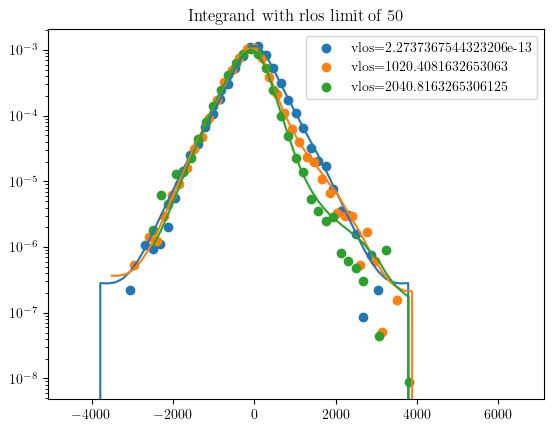

In [43]:

#for rlos_ind in range(len(rlos_cens)//10): #NOTE: Prediction from model and hists match up here, so it must be another issue. Maybe check for each vlos first, then move on to checking densities?
                                                   #Or is it due to cutoff vpec range? see orange curve below. 

res = np.zeros((len(Pints), len(vpec)))

for i, Pint in enumerate(Pints):
    #th = plt.hist(vphyslos[ind + m_ind*len(r_cens)], bins=np.flip(vpec), density=False, histtype='step', color='C0')
    #plt.plot(vr_grid, (np.sum(th[0])*Pint*np.diff(vr_grid)[0]), c='C2') #*(th[0] != 0)
    plt.plot(vpecs[i], Pint, c=f'C{i}') #*(th[0] != 0)
    plt.scatter(vpecs[i], Pints_hist[i] , c=f'C{i}', label=f'vlos={tvlc[vinds[i]]}') #*(th[0] != 0)
    res[i] = (Pint-Pints_hist[i])/Pints_hist[i]

    #print(np.sum(np.sum(th[0])*Pint*np.diff(vr_grid)[0])*np.diff(vr_grid)[0], np.sum(th[0])*np.diff(vr_grid)[0])
plt.title(f'Integrand with rlos limit of 50')
plt.yscale('log')
plt.legend()
plt.show()

(-2.0, 2.0)

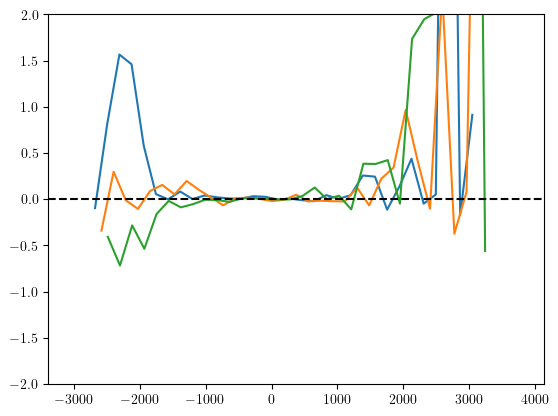

In [47]:
for i, Pint in enumerate(Pints):
    plt.plot(vpecs[i], res[i])

plt.axhline(0, c='k', ls='--')
plt.ylim((-2, 2))

In [22]:
Pvlos_interp_list = []
for j in range(len(rlos_vals)):
    interp_func = interp1d(vr_grid, Pvlos_grid[j], kind='linear', 
                        bounds_error=False, fill_value=0.0)
    interpolated = interp_func(vr_grid)

    Pvlos_interp_list.append(interpolated)


Pvlos_interp = np.array(Pvlos_interp_list)
Pvlos_interp = Pvlos_interp.T 

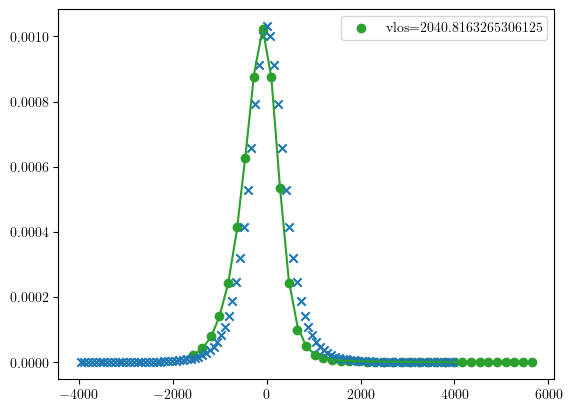

In [27]:
plt.plot(vpecs[i], Pint, c=f'C{i}') #*(th[0] != 0)
plt.scatter(vpecs[i], Pints_hist[i] , c=f'C{i}', label=f'vlos={tvlc[vinds[i]]}') #*(th[0] != 0)
plt.scatter(vr_grid, np.mean(Pvlos_grid, axis=0), marker='x')

#print(np.sum(np.sum(th[0])*Pint*np.diff(vr_grid)[0])*np.diff(vr_grid)[0], np.sum(th[0])*np.diff(vr_grid)[0])
#plt.yscale('log')
plt.legend()
plt.show()

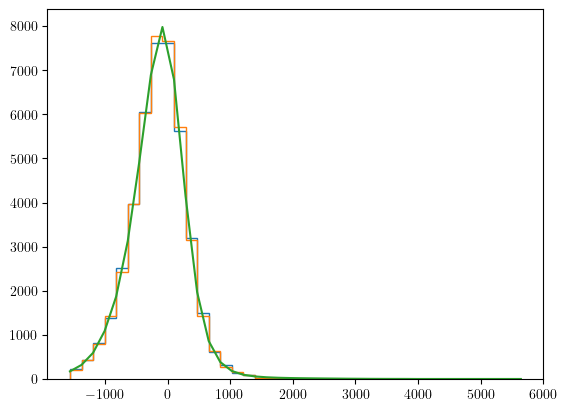

In [72]:
rlos_ind = 30

#th = plt.hist(vphyslos_int[rlos_ind + ind*len(rlos_cens) + m_ind*len(rlos_cens)*len(r_cens)]-a*H*rlos_cens[rlos_ind]/h, bins=vr_e, density=False, histtype='step', color='C0')



#th = plt.hist(vpeclos[rlos_ind + ind*len(rlos_cens) + m_ind*len(rlos_cens)*len(r_cens)]-a*H*rlos_cens[rlos_ind]/h, bins=vr_e, density=False, histtype='step', color='C0')
th = plt.hist(vphyslos_int[rlos_ind + ind*len(rlos_cens) + m_ind*len(rlos_cens)*len(r_cens)] - a*H*rlos_cens[rlos_ind]/h, bins=np.flip(vpec), density=False, histtype='step', color='C0')
th = plt.hist(vpeclos_ls[rlos_ind + ind*len(rlos_cens) + m_ind*len(rlos_cens)*len(r_cens)], bins=np.flip(vpec), density=False, histtype='step', color='C1')
#thh = plt.hist(vphyslos_int[rlos_ind + ind*len(rlos_cens) + m_ind*len(rlos_cens)*len(r_cens)], bins=vr_e, density=False, histtype='step', color='C1')
plt.plot(vpec, np.sum(th[0])*Pints[1]*np.diff(np.flip(vpec))[0], c='C2') #*(th[0] != 0)


#print(np.sum(np.sum(th[0])*Pvlos_grid[rlos_ind, :]*np.diff(vr_grid)[0])*np.diff(vr_grid)[0], np.sum(th[0])*np.diff(vr_grid)[0])

In [12]:
r_cens[10]

np.float64(14.5)

In [24]:
samp_path = '/spiff/cosweeney/simulations/MDPL2/data/Pvlos_models/'

Model_Samples = []

with h5.File(samp_path+'gal_model_bin_mass_samples_r_4_15.hdf5', 'r') as f:
    # Access specific sample set
    test_samples = f['vphyslos/0/10'][:]

    for k in range(len(Mvirs)):
        for i in range(len(r_cens[:11])):
                Model_Samples.append(f[f'vphyslos/{str(k)}/{str(i)}'][:])

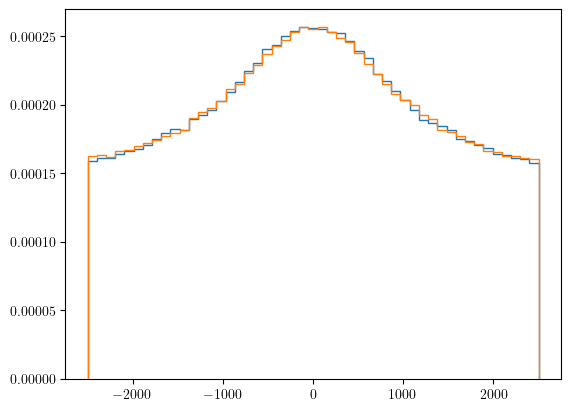

In [9]:
# confirmation: we have an error with the density profiles! NOTE: Check Sigma(R)? Still having discrepencies at low R... 

tvle = np.linspace(-2500, 2500, 50)
tvlc = 0.5*(tvle[1:]+tvle[:-1])

ind = 10
m_ind = 0
index = ind+m_ind*len(r_cens)
hist, _, _ = plt.hist(vphyslos[index], bins=tvle, density=True, histtype='step')

model_samples = test_samples#P_vphys_R_samples(ind, m_ind)
hist2, _, _ = plt.hist(model_samples, bins=tvle, density=True, histtype='step')


#model = P_vphys_R_vec(tvlc, r_cens[ind], Mvirs[m_ind]/1e14, joint_MAP)


#plt.plot(tvlc, model) 


(40, 49)


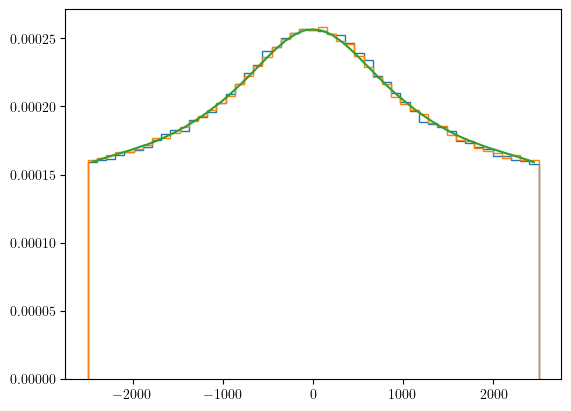

In [192]:
hist, _, _ = plt.hist(vphyslos[index], bins=tvle, density=True, histtype='step')
hist2, _, _ = plt.hist(model_samples, bins=tvle, density=True, histtype='step')

model = P_vphys_R_vec(tvlc, r_cens[ind], Mvirs[m_ind]/1e14, joint_MAP)

plt.plot(tvlc, model) 

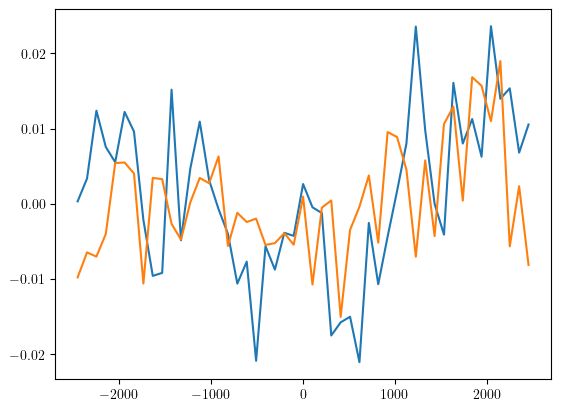

In [193]:
plt.plot(tvlc, (model-hist)/hist) 
plt.plot(tvlc, (model-hist2)/hist2) 

In [171]:
np.mean(np.abs((model-hist)/hist))

np.float64(0.008208755707354144)

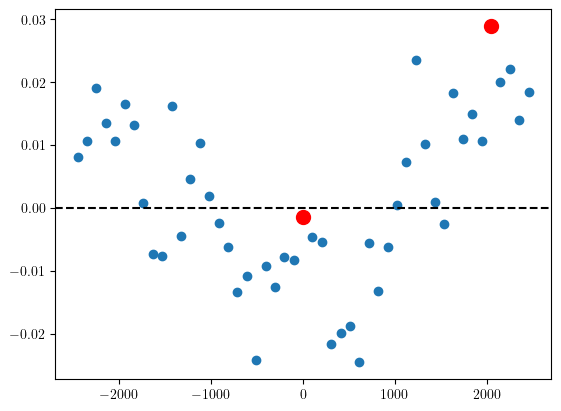

In [18]:
plt.scatter(tvlc, (model-hist)/hist)
plt.scatter(tvlc[24], (model-hist)[24]/hist[24], c='r', s=100)
plt.scatter(tvlc[44], (model-hist)[44]/hist[44], c='r', s=100)
plt.axhline(0, c='k', ls='--')

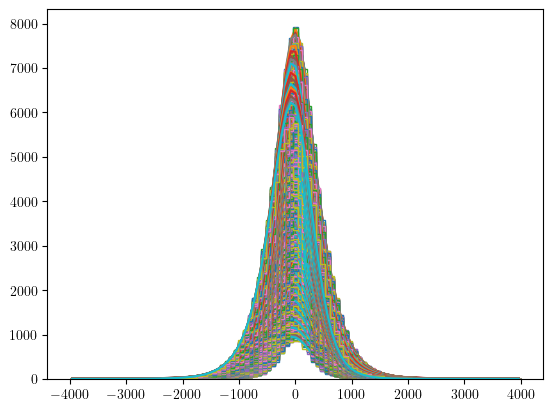

In [11]:
#rlos_ind = 0
differences = []
mses = []
for ind in range(len(r_cens)):
    for rlos_ind in range(len(rlos_cens)):
        model = P_vlos_R_rlos(vr_grid, r_cens[ind], rlos_cens[rlos_ind], M_test, pars)
        th = plt.hist(vpeclos_ls[rlos_ind + ind*len(rlos_cens) + m_ind*len(rlos_cens)*len(r_cens)], bins=vr_e, density=False, histtype='step')
        plt.plot(vr_grid, np.sum(th[0])*model*np.diff(vr_grid)[0])
        #plt.show()
        res = (np.sum(th[0])*model*np.diff(vr_grid)[0]-th[0])/th[0]
        differences.append((res*(th[0] != 0)))
        mses.append(np.mean((res**2)[~np.isinf(res)])) 


In [20]:
differences = np.array(differences).reshape(len(r_cens), len(rlos_cens), -1)
mses = np.array(mses).reshape(len(r_cens), len(rlos_cens))

In [27]:
differences.shape

(26, 40, 99)

In [19]:
MSE = np.array(mses).reshape((len(r_cens), len(rlos_cens)))

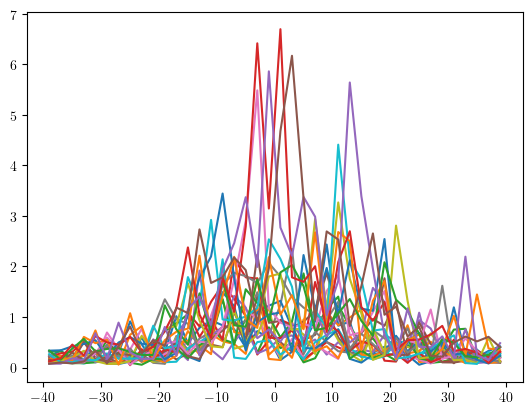

In [21]:
for i in range(len(r_cens)):
    plt.plot(rlos_cens, MSE[i, :])

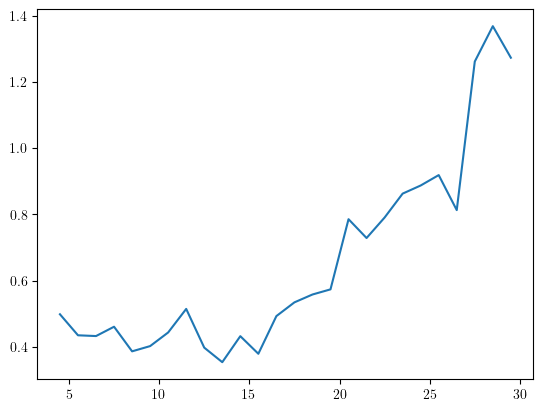

In [22]:
plt.plot(r_cens, np.mean(MSE, axis=1))

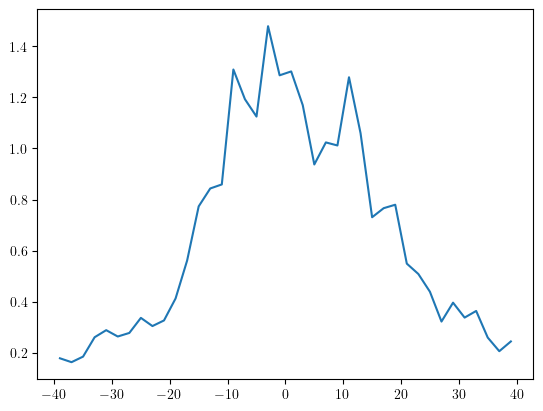

In [23]:
plt.plot(rlos_cens, np.mean(MSE, axis=0))

In [58]:
diffs = np.array(differences).reshape(len(r_cens), len(rlos_cens), len(vr_grid))

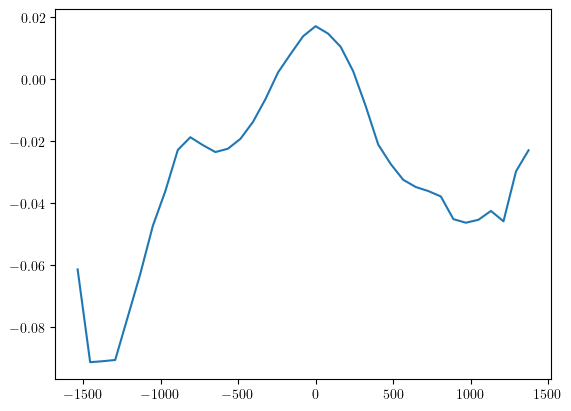

In [25]:
plt.plot(vr_grid, np.mean(np.mean(differences, axis=0), axis=0))

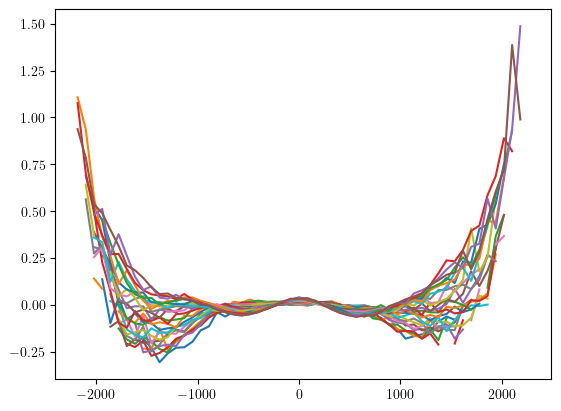

In [26]:
for i in range(len(r_cens)):
    plt.plot(vr_grid, np.mean(differences[i], axis=0)) 

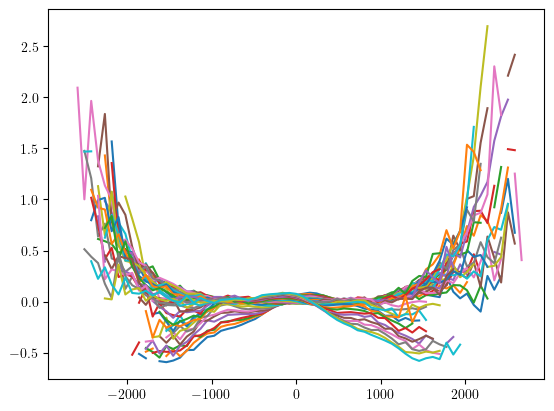

In [61]:
for i in range(len(rlos_cens)):
    plt.plot(vr_grid, np.mean(diffs[:, i], axis=0))

(-10.0, 10.0)

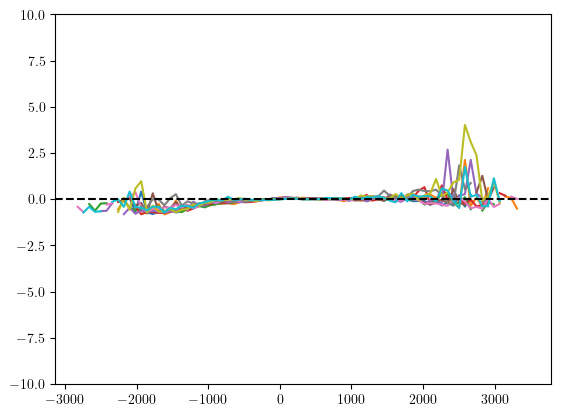

In [89]:
for rlos_ind in range(10):
    plt.plot(vr_grid, differences[rlos_ind])

plt.axhline(0, ls='--', c='k')
plt.ylim((-10, 10))

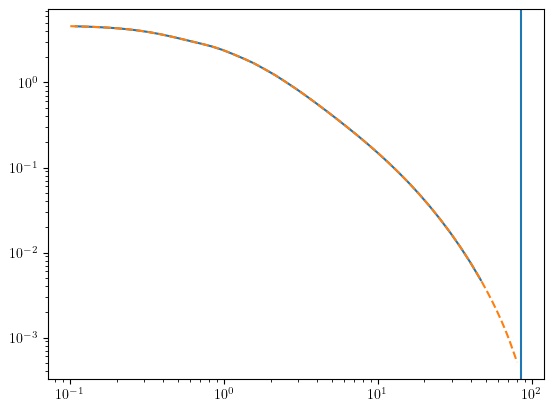

In [ ]:
# Is error w/ density profiles an issue? NOTE: revisit, with actual density data at these scales.

plt.plot(rxhg, zel_xhg)
plt.plot(full_r2d, zel2d, ls='--', c='C1')
plt.axvline(85)
plt.yscale('log')
plt.xscale('log')

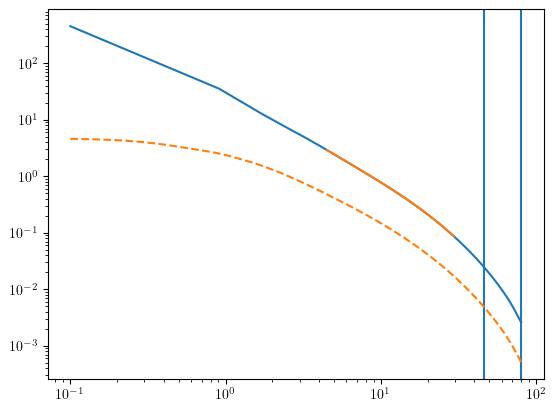

In [36]:
r_s = np.linspace(0.1, 80, 100)

plt.loglog(r_s, cf_inf(r_s, Mvirs[0], cf_pars))
plt.loglog(r_cens, cf_inf(r_cens, Mvirs[0], cf_pars)) 

plt.axvline(np.max(rxhg))
plt.axvline(80)
plt.plot(full_r2d, zel2d, ls='--', c='C1')


In [15]:
# compute num of halos per M bin for normalization later

halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'

N_halos = np.zeros(len(Mvirs))

with h5.File(halo_path, 'r') as hcat:
    for k in range(len(mbins)-1):
        mcut = (hcat['mvir'] > mbins[k]) & (hcat['mvir'] <= mbins[k+1])

        N_bin = mcut.sum()
        N_halos[k] = N_bin

In [63]:
with h5.File(halo_path, 'r') as hcat:
    print(hcat.keys())

<KeysViewHDF5 ['A[x]', 'A[x](500c)', 'A[y]', 'A[y](500c)', 'A[z]', 'A[z](500c)', 'Acc_Rate_1*Tdyn', 'Acc_Rate_100Myr', 'Acc_Rate_2*Tdyn', 'Acc_Rate_Inst', 'Acc_Rate_Mpeak', 'Acc_Scale', 'Breadth_first_ID', 'Depth_first_ID', 'First_Acc_Mvir', 'First_Acc_Scale', 'First_Acc_Vmax', 'Future_merger_MMP_ID', 'Halfmass_Scale', 'Jx', 'Jy', 'Jz', 'Last_mainleaf_depthfirst_ID', 'Last_progenitor_depthfirst_ID', 'Log_(Vmax', 'M200b', 'M200c', 'M2500c', 'M500c', 'M_pe_Behroozi', 'M_pe_Diemer', 'Macc', 'Mmvir_all', 'Mpeak', 'Mpeak_Scale', 'Next_coprogenitor_depthfirst_ID', 'Orig_halo_ID', 'Rs_Klypin', 'Snap_num', 'Spin', 'Spin_Bullock', 'T', 'Tidal_Force', 'Tidal_Force_Tdyn', 'Tidal_ID', 'Time_to_future_merger', 'Tree_root_ID', 'Vacc', 'Vmax\\@Mpeak', 'Voff', 'Vpeak', 'Xoff', 'b_to_a', 'b_to_a(500c)', 'c_to_a', 'c_to_a(500c)', 'desc_id', 'desc_pid', 'desc_scale', 'id', 'mmp?', 'mvir', 'num_prog', 'phantom', 'pid', 'rs', 'rvir', 'sam_mvir', 'scale', 'scale_of_last_MM', 'upid', 'vmax', 'vrms', 'vx', 'v

In [51]:
N_halos 

array([15071.,  8200.,  4095.,  1691.,   676.,   246.])

In [18]:
# let's look at the Surface density profiles
Sigma_RM = np.zeros((6, len(r_cens)))

with h5.File(vel_path, 'r') as hdf:

    for k in range(len(Mvirs)):
        
        Rs = hdf[f'R/{str(k)}'][()]

        for j in range(len(r_cens)):
            
            R_mask = (Rs >= r_edges[j])&(Rs <= r_edges[j+1])

            N_pairs = R_mask.sum()

            V_shell = np.pi * ( r_edges[j+1]**2 - r_edges[j]**2 ) 

            Sigma = N_pairs / N_halos[k] / V_shell 

            Sigma_RM[k, j] = Sigma

In [69]:
Sigma_inf(r_cens[0], Mvirs[k], cf_pars)

np.float64(3.317109763626198)

In [70]:
Sigma_inf(r_cens, Mvirs[k], cf_pars)

array([3.31710976, 3.09043243, 2.9212928 , 2.78737384, 2.67790824,
       2.58600647, 2.50740814, 2.43958901, 2.38005754, 2.32782795,
       2.28134967, 2.23976811, 2.20251579, 2.16887635, 2.1384584 ,
       2.11080256, 2.08560115, 2.06259305, 2.04137561, 2.02192741,
       2.00415428, 1.98776734, 1.97244252, 1.95833572, 1.94522249,
       1.93308952])

In [124]:
def cf_inf_new(r, M, params):
    b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu = params
    
    M_vp = 1e14
    B = 0.948
    r_h = (7.35305605e-01) * (M/1e14)**(2.80615822e-01)
    
    b = b_p * (M/M_vp)**b_s
    g = g_p * (M/M_vp)**g_s
    c = c0 * (1 - scipy.special.erf((np.log10(M/M_vp) - c_m) / c_sig)) / 2
    x = r / r_h
    
    # Always use vectorized interpolation
    zel_interp = np.interp(r, full_r2d, zel2d)
    
    corr_inf = b * ((1 + (r_inf / (mu*r_h + r))**g) / 
                    (1 + c * x * np.exp(-x))) * B * zel_interp
    
    return corr_inf

def surf_int_inf_vectorized(rlos, R, M, params):
    """R can be a scalar or array; rlos is the integration variable"""
    b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu = params
    
    # Ensure R is at least 1D for broadcasting
    R = np.atleast_1d(R)
    rlos = np.atleast_1d(rlos)
    
    # Broadcast: rlos[:, None] and R[None, :] creates (n_rlos, n_R) array
    r3d = np.sqrt(rlos[:, None]**2 + R[None, :]**2)
    
    a = 0.83760
    redshift = 1/a - 1
    h = cosmo.h
    H = h * 100 * cosmo.Ez(redshift)
    v_max = 4_000
    sigma = 532
    
    # cf_inf needs to handle 2D array input
    cf_values = cf_inf_new(r3d, M, params)
    
    result = 0.014 * (cf_values + 1) * (
        scipy.special.erf((v_max - a*H*rlos[:, None]) / np.sqrt(2) / sigma) + 1
    )
    
    return result

def Sigma_inf_new(R, M, params):
    from scipy.integrate import simpson
    
    R = np.atleast_1d(R)
    
    # Create integration grid (adaptive or fixed)
    rlos_grid = np.linspace(0, 80, 200)  # Adjust density as needed
    
    # Get integrand values for all R at once: shape (n_rlos, n_R)
    integrand = surf_int_inf_vectorized(rlos_grid, R, M, params)
    
    # Integrate along rlos axis (axis=0)
    result = simpson(integrand, x=rlos_grid, axis=0)
    
    return result[0] if len(result) == 1 else result

In [72]:
import time
R_test = np.linspace(0.1, 5, 5)

start = time.time()
result_old = Sigma_inf(R_test, M, cf_pars)
print(f"Old: {time.time() - start:.2f}s")

start = time.time()
result_new = Sigma_inf_new(R_test, M, cf_pars)
print(f"New: {time.time() - start:.2f}s")

Old: 27.82s
New: 0.00s


In [126]:
Sigmas = np.zeros((6, len(r_cens)))
for k in range(len(Mvirs)):
    S = Sigma_inf_new(r_cens, Mvirs[k], cf_pars)
    Sigmas[k] = S 

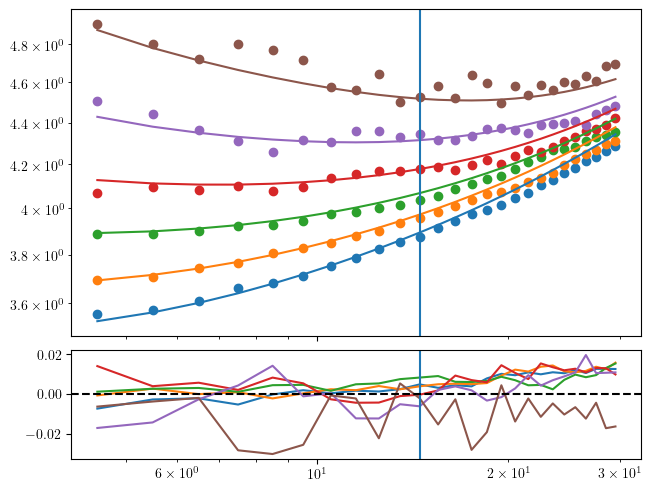

In [128]:
fig, ax = plt.subplots(2, 1, layout='constrained', sharex=1, gridspec_kw={'height_ratios': [3, 1]})

for k in range(len(Mvirs)):
    ax[0].scatter(r_cens, r_cens**0.25*Sigma_RM[k])
    ax[0].plot(r_cens, r_cens**0.25*Sigmas[k])

    ax[1].plot(r_cens, (Sigmas[k] - Sigma_RM[k])/Sigma_RM[k])

ax[0].axvline(r_cens[10])
ax[1].axvline(r_cens[10])
ax[0].set_yscale('log')
ax[0].set_xscale('log')

ax[1].axhline(0, c='k', ls='--')
ax[1].set_xscale('log')

In [129]:
with h5.File(vel_path, 'r') as hdf:
    print(hdf.keys())

<KeysViewHDF5 ['Mvir', 'R', 'r', 'rlos', 'vpeclos', 'vphyslos']>


In [130]:
# 3d profiles?
rho_RM = np.zeros((6, len(r_cens)))

with h5.File(vel_path, 'r') as hdf:

    for k in range(len(Mvirs)):
        
        rs = hdf[f'r/{str(k)}'][()]

        for j in range(len(r_cens)):
            
            r_mask = (rs >= r_edges[j])&(rs <= r_edges[j+1])

            N_pairs = r_mask.sum()

            V_shell = 4/3 *  np.pi * ( r_edges[j+1]**3 - r_edges[j]**3 ) 

            rho = N_pairs / N_halos[k] / V_shell 

            rho_RM[k, j] = rho


In [153]:
np.sqrt(r_cens[-1]**2 + rlos_cens**2) 

array([48.900409  , 47.32071428, 45.77390086, 44.26341605, 42.79310692,
       41.36725758, 39.9906239 , 38.6684626 , 37.40655023, 36.21118612,
       35.08917212, 34.04776057, 33.09456149, 32.23740064, 31.48412298,
       30.84234103, 30.31913587, 29.9207286 , 29.65215001, 29.51694429,
       29.51694429, 29.65215001, 29.9207286 , 30.31913587, 30.84234103,
       31.48412298, 32.23740064, 33.09456149, 34.04776057, 35.08917212,
       36.21118612, 37.40655023, 38.6684626 , 39.9906239 , 41.36725758,
       42.79310692, 44.26341605, 45.77390086, 47.32071428, 48.900409  ])

In [16]:
r_fine_e = np.linspace(4.5, 50, 100)
r_fine_cens = 0.5*(r_fine_e[1:] + r_fine_e[:-1])

rho_RM_fine = np.zeros((6, len(r_fine_cens)))

with h5.File(vel_path, 'r') as hdf:

    for k in range(len(Mvirs)):
        
        rs = hdf[f'r/{str(k)}'][()]

        for j in range(len(r_fine_cens)):
            
            r_mask = (rs >= r_fine_e[j])&(rs <= r_fine_e[j+1])

            N_pairs = r_mask.sum()

            V_shell = 4/3 *  np.pi * ( r_fine_e[j+1]**3 - r_fine_e[j]**3 ) 

            rho = N_pairs / N_halos[k] / V_shell 

            rho_RM_fine[k, j] = rho

In [136]:
rhos = np.zeros((6, len(r_cens)))
for k in range(len(Mvirs)):
    S = cf_inf(r_cens, Mvirs[k], cf_pars)
    rhos[k] = S 

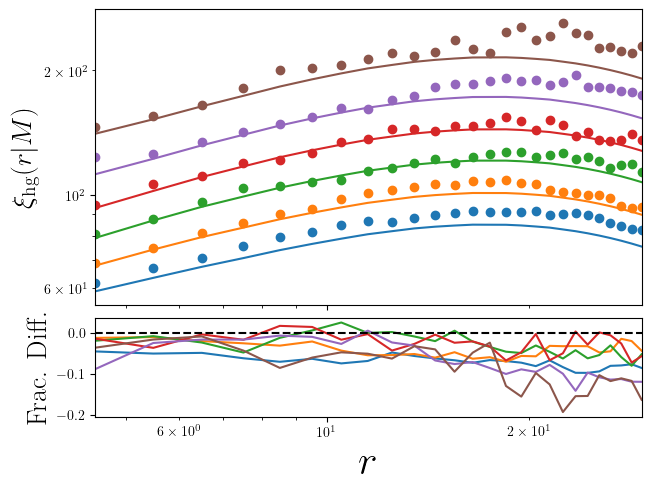

In [178]:
fig, ax = plt.subplots(2, 1, layout='constrained', sharex=1, gridspec_kw={'height_ratios': [3, 1]})

for k in range(len(Mvirs)):
    ax[0].scatter(r_cens, r_cens**2*(rho_RM[k]/0.014 - 1), label=r'MDPL2')
    ax[0].plot(r_cens, r_cens**2*rhos[k], label=r'MAP Model')

    ax[1].plot(r_cens, (rhos[k] - (rho_RM[k]/0.014 - 1))/(rho_RM[k]/0.014 - 1))

#ax[0].axvline(r_cens[10])
#ax[1].axvline(r_cens[10])
ax[0].set_yscale('log')
ax[0].set_xscale('log')

ax[1].axhline(0, c='k', ls='--') 
ax[1].set_xscale('log')

ax[0].set_ylabel(r'$\xi_{\rm hg}(r|M)$', fontsize=20)
ax[1].set_ylabel(r'Frac. Diff.', fontsize=20)
ax[1].set_xlabel(r'$r$', fontsize=30)

ax[0].margins(x=0)
ax[1].margins(x=0)

0.0
(60, 50)


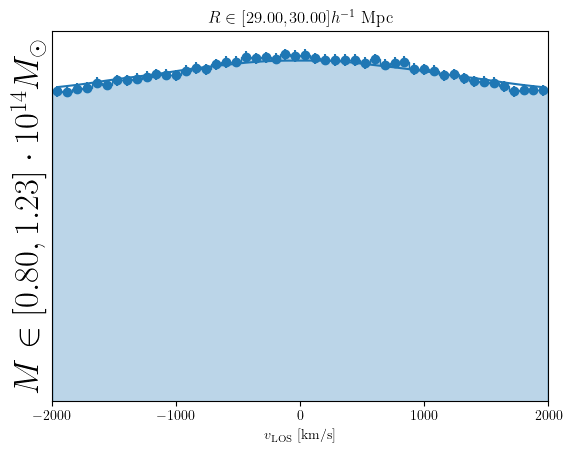

In [5]:

ls_edges = np.linspace(30, 51, 51-30+1)
ls_cens = (ls_edges[1:]+ls_edges[:-1])/2.0

M_select_indices = [0, 5]
M_select_edges = [mbins[i:i+2] for i in M_select_indices] 
M_select_cens = [Mvirs[i] for i in M_select_indices] 

# bins for plots
ls_select_indices = [0, 10, 20]
ls_select_edges = [ls_edges[i:i+2] for i in ls_select_indices] #[edges[2:4], edges[7:9], edges[20:22]]
ls_select_cens = [ls_cens[i] for i in ls_select_indices] #[cens[2], cens[7], cens[20]]

# radial bins
edges = np.linspace(4, 30, 26+1)
cens = (edges[1:]+edges[:-1])/2.0

# bins for plots
select_indices = [0, 10, 25]
select_edges = [edges[i:i+2] for i in select_indices] #[edges[2:4], edges[7:9], edges[20:22]]
select_cens = [cens[i] for i in select_indices] #[cens[2], cens[7], cens[20]]


a = 0.83760
H = 74.71913613009617
h = 0.6777 # damn you, little h!

convs = [conv_BGS, conv_LRG]
conv_label = ['BGS', 'LRG']

k = 0
i = 2
j = 0



R = cens[select_indices[i]] #np.sqrt(np.mean(Rdata[nbins*select_indices[i]+select_indices[j]]**2))

index2 = select_indices[i] + M_select_indices[k]*len(cens)

nphys2, bins = np.histogram(vphyslos_ls[index2], bins=50, range=(-2_000, 2_000), density = False) #vxs[valid_ind_smooth], vxs[-valid_ind_smooth] #range=(test_vc[valid_ind], test_vc[-valid_ind])
nphys2 = nphys2*convs[j] #/np.sum(nphys*dv) #*convs[j]

cent = (bins[:-1] + bins[1:])/2.
cent = cent 
dv = np.diff(bins)[0]

#            print(cens[select_indices[i]], Mvirs[M_select_indices[k]]/1e14)
#model = P_vlos_R_romb(vxs, cens[select_indices[i]], Mvirs[M_select_indices[k]])

vxs = cent#np.linspace(-4_000, 4_000, 150) 

model_dist = P_vphys_R_vec(vxs, cens[select_indices[i]], Mvirs[M_select_indices[k]]/1e14, pars=joint_MAP)
model_dist = model_dist / np.sum(model_dist*np.diff(vxs)[0])#[valid_ind_smooth:-valid_ind_smooth]
model_phys2 = np.sum(nphys2)*model_dist*np.diff(cent)[0] 

# model_dist2 = P_vphys_R_int(mvirs[k])[:, select_indices[i]]#P_vphys_R_vec(vxs, cens[select_indices[i]], mvirs[k], pars=joint_MAP)
# model_dist2 = model_dist2 / np.sum(model_dist2*np.diff(cent)[0])#[valid_ind_smooth:-valid_ind_smooth]
# model_phys2 = np.sum(nphys)*model_dist2*np.diff(cent)[0] 


#PD[j, k, i, :] = (model_phys - nphys)/nphys
#PD_BF[j, k, i, :] = (model_phys2 - nphys)/nphys 

#plt.hist(cent, bins=bins, weights=n, color="C0", histtype='stepfilled', alpha=0.3, label=r'$v_{\rm pec, LOS}$') 
#plt.hist(cent, bins=bins, weights=n, color="C0", histtype='step') 

plt.hist(cent, bins=bins, weights=nphys2, color=f"C{str(j)}", histtype='stepfilled', alpha=0.3)
plt.hist(cent, bins=bins, weights=nphys2, color=f"C{str(j)}", histtype='step')
plt.errorbar(cent, nphys2, np.sqrt(nphys2), fmt='o', c=f'C{str(j)}')

#plt.plot(cent, model, color="C0")
plt.plot(vxs, model_phys2, color=f"C{str(j)}", label=conv_label[j])
#plt.plot(cent, model_phys2, color=f"C{str(j)}", label=conv_label[j], ls='--')
#plt.plot(vcens,  np.sum(nphys)*P_vphys_R_int(Mvirs[M_select_indices[k]]/1e14)[:, select_indices[i]]*np.diff(cent)[0], color='C0', ls='--')
plt.xlabel(r'$v_{\rm LOS}$ [km/s]')
plt.ylabel(r'$M \in [{:.2f}, {:.2f}] \cdot 10^{{14}} M_\odot$'.format(M_select_edges[k][0]/1e14, M_select_edges[k][1]/1e14), fontsize=25)
plt.yticks([])
plt.xticks([-2000, -1000, 0, 1000, 2000])
plt.xlim((-2_000, 2_000)) #(vxs[valid_ind_smooth], vxs[-valid_ind_smooth])
plt.xlim((-2_000, 2_000)) #(vxs[valid_ind_smooth], vxs[-valid_ind_smooth])
plt.title(r'$R \in [{:.2f}, {:.2f}] h^{{-1}}$ Mpc'.format(select_edges[i][0], select_edges[i][1]))
plt.margins(x=0)

In [10]:
def P_vphys_R_samples(ind, m_ind):
    index = ind + m_ind*len(r_cens)

    test_vlos = vphyslos_ls[index] 
    test_R = R_ls[index]
    test_rlos = rlos_ls[index]

    # Now you can vectorize the entire operation:
    r_distances = np.sqrt(r_cens[ind]**2 + test_rlos**2)

    # Single call instead of 52,000 calls!
    rad_samps, tan_samps, masks = joint_dist_samples(
        N=len(r_distances), 
        r=r_distances, 
        M=Mvirs[m_ind], 
        pars=joint_MAP
    )

    # Stack into the format you need
    samp_vr_vt = np.stack([rad_samps, tan_samps], axis=1)[:, :, np.newaxis]

    h = cosmo.h 
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)
    theta_test = np.arctan2(test_rlos, r_cens[ind]) 

    cos_test = np.cos(theta_test)
    sin_test = np.sin(theta_test)

    vpeclos_test =  samp_vr_vt[:, 0, 0]*sin_test + samp_vr_vt[:, 1, 0]*cos_test 

    vphyslos_test = vpeclos_test + a*H*test_rlos / h 

    return vphyslos_test

In [11]:
# compute model samples for below plot, save 
import pickle

M_select_indices = [0, 5]
M_select_edges = [mbins[i:i+2] for i in M_select_indices] 
M_select_cens = [Mvirs[i] for i in M_select_indices] 


# radial bins
edges = np.linspace(4, 30, 26+1)
cens = (edges[1:]+edges[:-1])/2.0

# bins for plots
select_indices = [0, 10, 25]
select_edges = [edges[i:i+2] for i in select_indices] #[edges[2:4], edges[7:9], edges[20:22]]
select_cens = [cens[i] for i in select_indices] #[cens[2], cens[7], cens[20]]

Model_Samples = []

k = 0
i = 0
j = 0 
for k in range(len(M_select_cens)):
    for i in tqdm(range(len(select_cens))):
        model_samples = P_vphys_R_samples(select_indices[i], M_select_indices[k]) #NOTE: try later with individual masses instead of bin mass. any difference?
        Model_Samples.append(model_samples)


100%|██████████| 3/3 [00:34<00:00, 11.37s/it]


FileNotFoundError: [Errno 2] No such file or directory: 'spiff/cosweeney/simulations/MDPL2/data/velocity_distributions/plot_model_samples.pkl'

In [12]:

save_path = '/spiff/cosweeney/simulations/MDPL2/data/velocity_distributions/'

with open(save_path+'plot_model_samples.pkl', 'wb') as file:
    pickle.dump(Model_Samples, file)

In [49]:
len(vpeclos)

7800

In [52]:
rho_RM_fine.shape

(6, 99)

In [18]:
rlos_edges = np.linspace(-40, 40, 40+1)  # reduced num of bins
rlos_cens = 0.5*(rlos_edges[1:]+rlos_edges[:-1]) 

def P_vphys_R_vec_simdens(v_phys, R, M, pars): 
    M = M * 1e14

    h = cosmo.h 
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    rlos_vals = rlos_cens

    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 

    vpec_data_max = np.max(vpec) #4000.0
    #print(1.5*vpec_data_max//np.diff(v_phys)[0] +1)

    vr_e = np.linspace(-4000 , 4000 , 100)
    vr_grid = 0.5*(vr_e[1:]+vr_e[:-1])

    Pvlos_grid = np.array([P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals])  
    #print(np.sum(np.isnan(Pvlos_grid))/len(Pvlos_grid.flatten())) 

    from scipy.interpolate import interp1d

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):
        interp_func = interp1d(vr_grid, Pvlos_grid[j], kind='linear', 
                            bounds_error=False, fill_value=0.0)
        interpolated = interp_func(vpec[:, j])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list)
    print(Pvlos_interp.shape)
    Pvlos_interp = Pvlos_interp.T 

    v_max = 4_000
    sigma = 532#418

    r3d = np.sqrt(R**2 + rlos_vals**2)
    #print(np.max(r3d), np.min(r3d))
    r_ind = np.where(R == r_cens)[0][0]
    m_ind = np.where(M == Mvirs)[0][0]
    rho_interp = interp1d(r_fine_cens, rho_RM_fine[m_ind], kind='linear', bounds_error=False, fill_value=0.0)(r3d)
    weight = rho_interp #
    #weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)#*0.5*( scipy.special.erf( (v_max - a*H*np.abs(rlos_vals))/ np.sqrt(2) / sigma ) + 1)

    integrand = Pvlos_interp * weight[None, :]
    from scipy.integrate import simpson
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_RM[m_ind, r_ind] #Sigma_inf(R, M, cf_pars)
    P_out /= sigma_R

    return P_out / np.sum(P_out*np.diff(v_phys)[0])

def P_vphys_R_fromhists(v_phys, R_ind, M_ind):
    R = r_cens[R_ind]
    M = Mvirs[M_ind] # * 1e14

    h = cosmo.h 
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    rlos_vals = rlos_cens

    vpec_data_max = 4000.0

    vr_e = np.linspace(-vpec_data_max, vpec_data_max, 100+1)
    vr_grid = 0.5*(vr_e[1:]+vr_e[:-1])

    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 

    vels = vpeclos_ls

    Pvlos_grid = []
    for ind in range(len(rlos_cens)):
        vel_data = vels[ind + R_ind*len(rlos_cens) + M_ind*len(r_cens)*len(rlos_cens)]
        
        # Count histogram
        hist, _ = np.histogram(vel_data, bins=vr_e, density=False)

        
        Pvlos_grid.append(hist)

    Pvlos_grid = np.array(Pvlos_grid)
    Pvlos_grid = np.nan_to_num(Pvlos_grid, 0.0)
    #print(np.sum(np.isnan(Pvlos_grid))/len(Pvlos_grid.flatten()))


    from scipy.interpolate import interp1d

    Pvlos_interp_list = []

    # Compute valid mask
    valid_mask = np.zeros((len(v_phys), len(rlos_vals)), dtype=bool)
    for j, rlos in enumerate(rlos_vals):
        v_phys_min_valid = -vpec_data_max + a * H * rlos / h
        v_phys_max_valid = vpec_data_max + a * H * rlos / h
        valid_mask[:, j] = (v_phys >= v_phys_min_valid) & (v_phys <= v_phys_max_valid)
    #print(valid_mask.shape)

    for j in range(len(rlos_vals)):
        interp_func = interp1d(vr_grid, Pvlos_grid[j], kind='linear', 
                            bounds_error=False, fill_value=0.0)
        interpolated = interp_func(vpec[:, j])
        interpolated[~valid_mask[:, j]] = 0.0
        
        bin_width = np.diff(vpec[:, j])[0]
        cumsum = np.cumsum(interpolated)*bin_width
        
        if cumsum[-1] < 0.999:
            interpolated = interpolated * (1 - cumsum[-1]) 

        Pvlos_interp_list.append(interpolated)


    Pvlos_interp = np.array(Pvlos_interp_list)
    Pvlos_interp = Pvlos_interp.T 
    #print(np.sum(np.isnan(Pvlos_interp)))

    v_max = 4000
    sigma = 532
    r3d = np.sqrt(R**2 + rlos_vals**2)
    rho_interp = interp1d(r_fine_cens, rho_RM_fine[M_ind], kind='linear', bounds_error=False, fill_value=0.0)(r3d)
    weight = rho_interp
    #weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)*0.5*( scipy.special.erf( (v_max - a*H*np.abs(rlos_vals))/ np.sqrt(2) / sigma ) + 1)

    integrand = Pvlos_interp * weight[None, :]
    from scipy.integrate import simpson
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_RM[M_ind, R_ind] #Sigma_inf(R, M, cf_pars)
    P_out /= sigma_R

    dv = np.diff(v_phys)[0]

    return P_out / np.sum(P_out) / dv

def P_vphys_R_vec(v_phys, R, M, pars): 
    M = M * 1e14

    h = cosmo.h 
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    rlos_vals = rlos_cens

    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 

    vpec_data_max = np.max(vpec) #4000.0
    #print(1.5*vpec_data_max//np.diff(v_phys)[0] +1)

    vr_e = np.linspace(-2500 , 2500 , 200)
    vr_grid = 0.5*(vr_e[1:]+vr_e[:-1])

    Pvlos_grid = np.array([P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals])  
    #print(np.sum(np.isnan(Pvlos_grid))/len(Pvlos_grid.flatten())) 

    from scipy.interpolate import interp1d

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):
        interp_func = interp1d(vr_grid, Pvlos_grid[j], kind='linear', 
                            bounds_error=False, fill_value=0.0)
        interpolated = interp_func(vpec[:, j])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list)
    print(Pvlos_interp.shape)
    Pvlos_interp = Pvlos_interp.T 

    v_max = 4_000
    sigma = 532 #418

    r3d = np.sqrt(R**2 + rlos_vals**2)
    #print(np.max(r3d), np.min(r3d))
    # r_ind = np.where(R == r_cens)[0][0]
    # m_ind = np.where(M == Mvirs)[0][0]
    # rho_interp = interp1d(r_fine_cens, rho_RM_fine[m_ind], kind='linear', bounds_error=False, fill_value=0.0)(r3d)
    # weight = rho_interp #
    weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)#*0.5*( scipy.special.erf( (v_max - a*H*np.abs(rlos_vals))/ np.sqrt(2) / sigma ) + 1)

    integrand = Pvlos_interp * weight[None, :]
    from scipy.integrate import simpson
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, cf_pars)
    P_out /= sigma_R

    return P_out / np.sum(P_out*np.diff(v_phys)[0])


In [21]:
len(Model_Samples)

60

In [23]:
len(Mvirs)*len(r_cens[:11])

66

In [33]:
r_cens[6]

np.float64(10.5)

  0%|          | 0/3 [00:00<?, ?it/s]

(40, 50)


 33%|███▎      | 1/3 [00:10<00:21, 10.57s/it]

(np.float64(6903.508747495637), np.float64(31749.50718419418))
(40, 50)


 67%|██████▋   | 2/3 [00:20<00:10, 10.26s/it]

...

 67%|██████▋   | 2/3 [00:20<00:10, 10.13s/it]

(np.float64(56.78060469538263), np.float64(1185.6156348749787))
(40, 50)


100%|██████████| 3/3 [00:29<00:00,  9.99s/it]

(np.float64(56.78060469538263), np.float64(1185.6156348749787))


Text(0.5, 0.98, '$P(v_{\\rm LOS}|R, M)$')

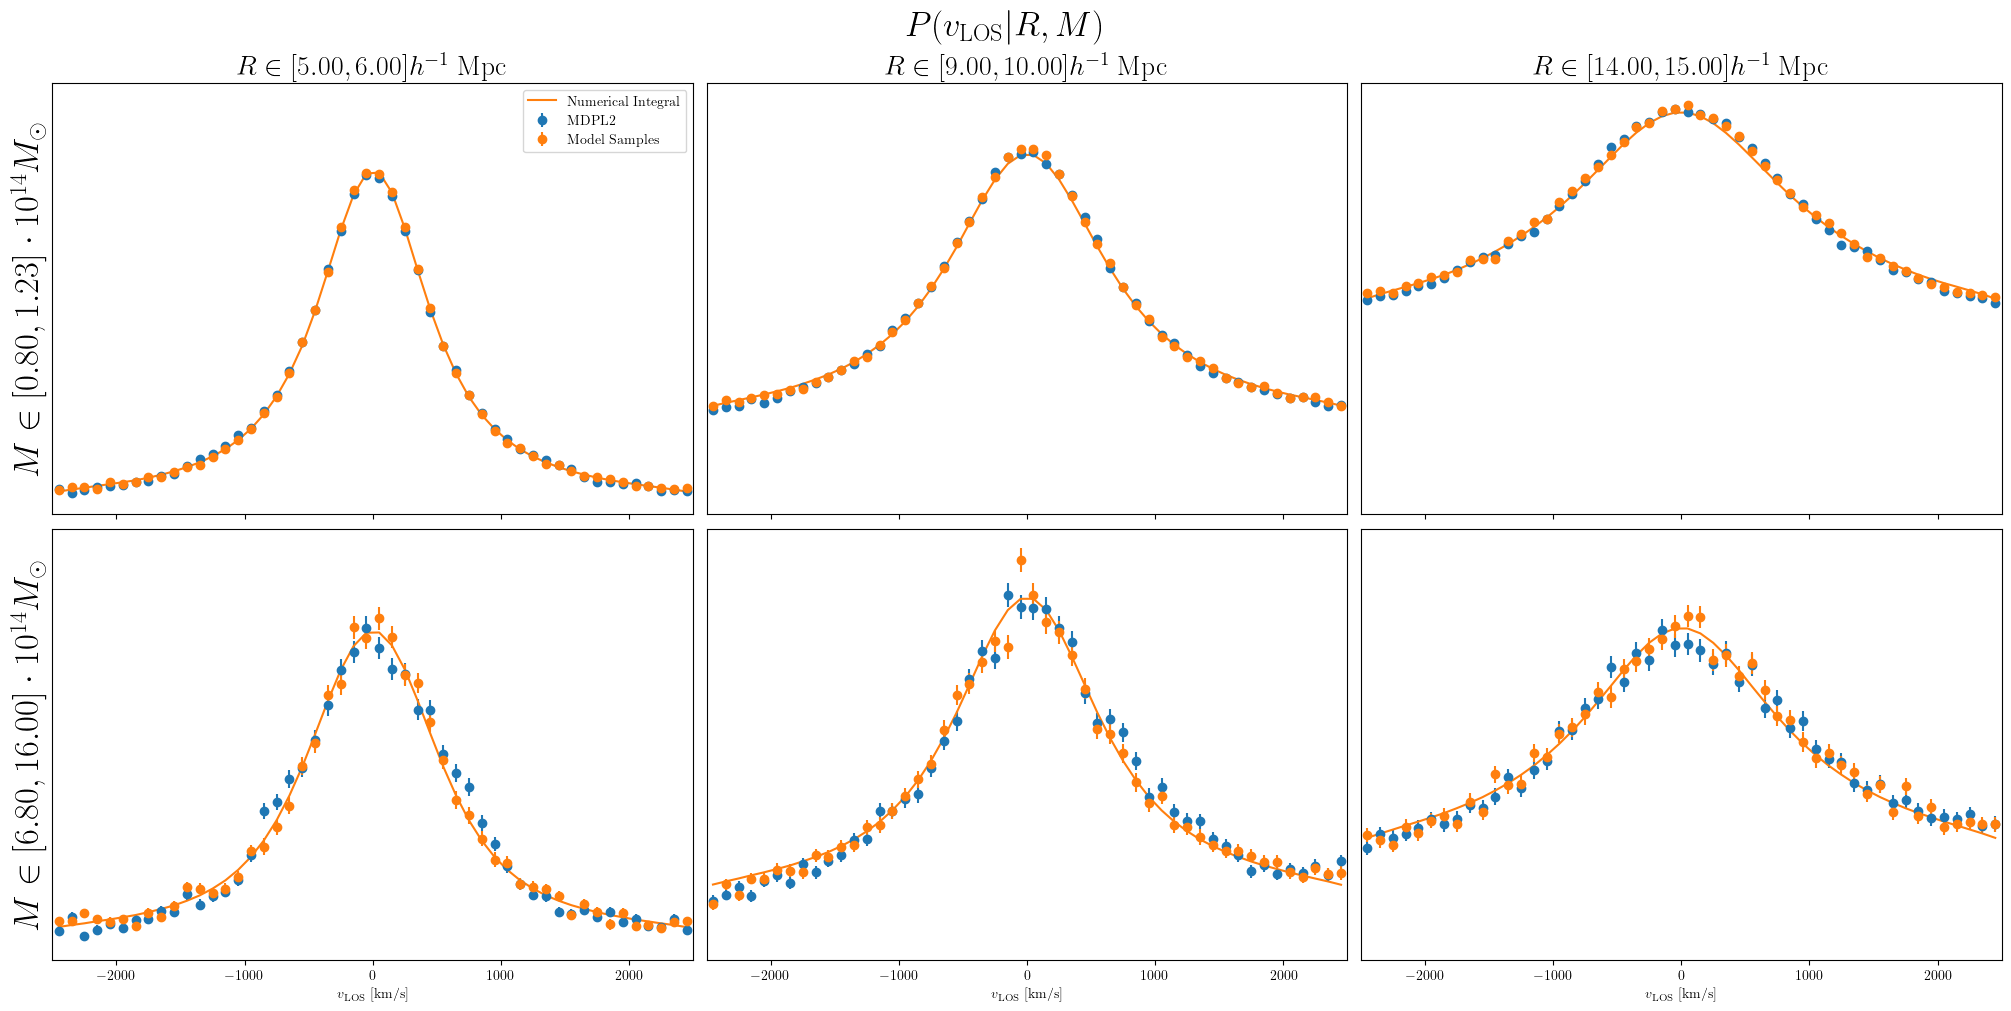

In [34]:
ls_edges = np.linspace(30, 51, 51-30+1)
ls_cens = (ls_edges[1:]+ls_edges[:-1])/2.0

M_select_indices = [0, 5]
M_select_edges = [mbins[i:i+2] for i in M_select_indices] 
M_select_cens = [Mvirs[i] for i in M_select_indices] 

# bins for plots
ls_select_indices = [0, 10, 20]
ls_select_edges = [ls_edges[i:i+2] for i in ls_select_indices] #[edges[2:4], edges[7:9], edges[20:22]]
ls_select_cens = [ls_cens[i] for i in ls_select_indices] #[cens[2], cens[7], cens[20]]

# radial bins
edges = np.linspace(4, 30, 26+1)
cens = (edges[1:]+edges[:-1])/2.0

# bins for plots
select_indices = [1, 5, 10]
select_edges = [edges[i:i+2] for i in select_indices] #[edges[2:4], edges[7:9], edges[20:22]]
select_cens = [cens[i] for i in select_indices] #[cens[2], cens[7], cens[20]]


fig, ax = plt.subplots(2, 3, figsize=(20, 10), layout='constrained', sharex=True, sharey='row')

a = 0.83760
H = 74.71913613009617
h = 0.6777 # damn you, little h!

convs = [conv_BGS, conv_LRG]
conv_label = ['BGS', 'LRG']

PD = np.zeros((2, 2, 3, 50))
PD_BF = np.zeros(PD.shape)

k = 0
i = 0
j = 0 
for k in range(len(M_select_cens)):
    for i in tqdm(range(len(select_cens))):
        vxs = np.linspace(-2_500, 2_500, 150) 
        R = cens[select_indices[i]] 

        index2 = select_indices[i] + M_select_indices[k]*len(cens)

        nphys, bins = np.histogram(vphyslos_ls[index2], bins=50, range=(-2_500, 2_500), density = False) 
        cent = (bins[:-1] + bins[1:])/2.
        dv = np.diff(bins)[0]

        model_samples = Model_Samples[select_indices[i] + M_select_indices[k]*len(r_cens[:11])] #P_vphys_R_samples(select_indices[i], M_select_indices[k]) #NOTE: try later with individual masses instead of bin mass. any difference?
        nphys_model, bins = np.histogram(model_samples, bins=50, range=(-2_500, 2_500), density = False) 

        model_dist = P_vphys_R_vec(cent, cens[select_indices[i]], Mvirs[M_select_indices[k]]/1e14, pars=joint_MAP)
        #model_dist = model_dist / np.sum(model_dist*np.diff(vxs)[0])#[valid_ind_smooth:-valid_ind_smooth]
        model_phys = np.sum(nphys)*model_dist*np.diff(cent)[0] 

        PD[0, k, i] = (model_phys - nphys)/nphys
        PD[1, k, i] = (model_phys - nphys_model)/nphys_model 

        #ax[k, i].hist(cent, bins=bins, weights=nphys, color=f"C{str(j)}", histtype='stepfilled', alpha=0.3)
        #ax[k, i].hist(cent, bins=bins, weights=nphys, color=f"C{str(j)}", histtype='step')
        #ax[k, i].hist(cent, bins=bins, weights=nphys_model, color=f"C{str(j+1)}", histtype='step')
        ax[k, i].errorbar(cent, nphys, np.sqrt(nphys), fmt='o', c=f'C0', label='MDPL2')
        ax[k, i].errorbar(cent, nphys_model, np.sqrt(nphys), fmt='o', c=f'C1', label="Model Samples")

        ax[k, i].plot(cent, model_phys, color=f"C1", label="Numerical Integral")
        ax[1, i].set_xlabel(r'$v_{\rm LOS}$ [km/s]')
        ax[k, 0].set_ylabel(r'$M \in [{:.2f}, {:.2f}] \cdot 10^{{14}} M_\odot$'.format(M_select_edges[k][0]/1e14, M_select_edges[k][1]/1e14), fontsize=25)
        ax[k, i].set_yticks([])
        ax[1, i].set_xticks([-2000, -1000, 0, 1000, 2000])
        ax[1, i].set_xlim((-2_500, 2_500)) #(vxs[valid_ind_smooth], vxs[-valid_ind_smooth])
        ax[0, i].set_xlim((-2_500, 2_500)) #(vxs[valid_ind_smooth], vxs[-valid_ind_smooth])
        ax[0, i].set_title(r'$R \in [{:.2f}, {:.2f}] h^{{-1}}$ Mpc'.format(select_edges[i][0], select_edges[i][1]), fontsize=20)
        ax[0, i].margins(x=0)
        print(ax[k, i].get_ylim())

ax[0, 0].legend(loc='upper right', fontsize=10)

fig.suptitle(r"$P(v_{\rm LOS}|R, M)$", fontsize=25)  

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 121.19it/s]


Text(0.5, 0.98, '$P(v_{\\rm LOS}|R, M)$ Residuals')

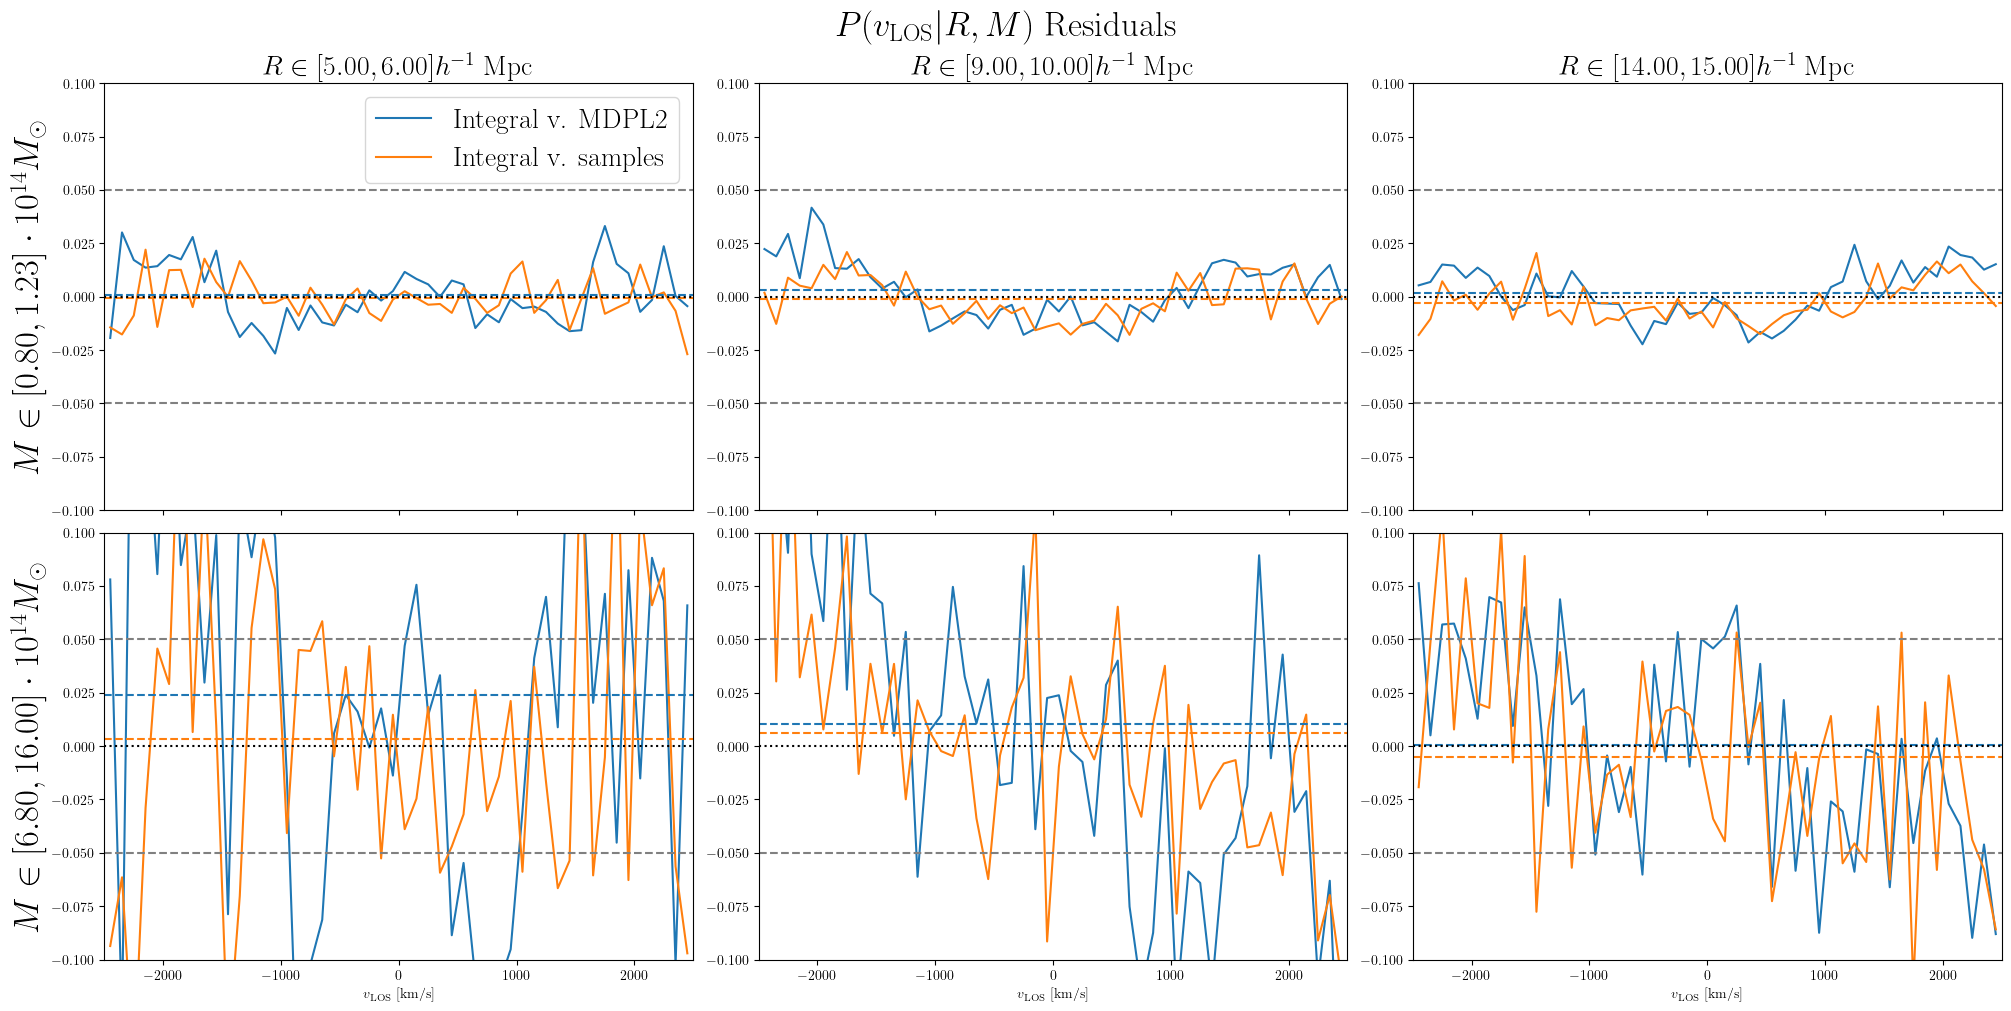

In [36]:
fig, ax = plt.subplots(2, 3, figsize=(20, 10), layout='constrained', sharex=True)

for k in range(len(M_select_cens)):
    for i in tqdm(range(len(select_cens))):
        ax[k, i].plot(cent, PD[0, k, i], label='Integral v. MDPL2')
        ax[k, i].plot(cent, PD[1, k, i], label='Integral v. samples')

        ax[k, i].axhline(np.mean(PD[0, k, i]), c=f'C0', ls='--')
        ax[k, i].axhline(np.mean(PD[1, k, i]), c=f'C1', ls='--')        

        ax[k, i].axhline(0, ls=':', c='k')
        ax[k, i].axhline(-0.05, ls='--', c='gray')
        ax[k, i].axhline(0.05, ls='--', c='gray')
        ax[1, i].set_xlabel(r'$v_{\rm LOS}$ [km/s]')
        ax[k, 0].set_ylabel(r'$M \in [{:.2f}, {:.2f}] \cdot 10^{{14}} M_\odot$'.format(M_select_edges[k][0]/1e14, M_select_edges[k][1]/1e14), fontsize=25)
        #ax[k, i].set_yticks([])
        ax[k, i].set_ylim((-0.1, 0.1))
        ax[1, i].set_xticks([-2000, -1000, 0, 1000, 2000])
        ax[1, i].set_xlim((-2_500, 2_500)) #(vxs[valid_ind_smooth], vxs[-valid_ind_smooth])
        ax[0, i].set_xlim((-2_500, 2_500)) #(vxs[valid_ind_smooth], vxs[-valid_ind_smooth])
        ax[0, i].set_title(r'$R \in [{:.2f}, {:.2f}] h^{{-1}}$ Mpc'.format(select_edges[i][0], select_edges[i][1]), fontsize=20)
        ax[0, i].margins(x=0)
ax[0, 0].legend(loc='upper right', fontsize=20)
fig.suptitle(r"$P(v_{\rm LOS}|R, M)$ Residuals", fontsize=25)

In [130]:
def P_vlos_R_rlos_quad(vlos, R, r_los, M, pars):
    """
    Compute P(v_los | R, r_los) using scipy.integrate.quad.
    
    Args:
        vlos (np.ndarray or float): Line-of-sight velocity bin centers.
        R (float): Projected radius.
        r_los (float): Line-of-sight distance.
        M (float): Halo mass.
        pars: Model parameters
    
    Returns:
        P_vlos (np.ndarray): Probability density evaluated at each v_los bin center. 
    """
    # distance relations
    theta = np.arctan2(R, r_los)
    r = np.sqrt(R**2 + r_los**2)
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    
    # Build joint distribution for interpolation
    vr_grid = np.linspace(-4000, 4000, 200)
    vt_grid = np.linspace(-4000, 4000, 200)
    
    JD = joint_dist(vr_grid, vt_grid, r, M, pars)
    JD = np.nan_to_num(JD, nan=0.0)
    
    # Create interpolator
    JD_interp = RectBivariateSpline(vr_grid, vt_grid, JD.T, s=0, kx=3, ky=3)
    
    # Define integrand for a single vlos value
    def integrand_single_vlos(vr, vlos_val):
        vt_val = (vlos_val - vr * sin_theta) / cos_theta
        # Check bounds to avoid extrapolation issues
        if vt_val < vt_grid.min() or vt_val > vt_grid.max():
            return 0.0
        return JD_interp.ev(vr, vt_val) / abs(cos_theta)
    
    # Handle scalar or array vlos
    vlos = np.atleast_1d(vlos)
    P_out = np.zeros_like(vlos, dtype=float)
    
    for i, v in enumerate(vlos):
        result, error = quad(integrand_single_vlos, vr_grid.min(), vr_grid.max(), 
                            args=(v,), limit=100, epsabs=1e-10, epsrel=1e-8)
        P_out[i] = result
    
    # Normalize
    dv = np.diff(vlos)[0] if len(vlos) > 1 else 1.0
    P_sum = np.sum(P_out) * dv
    
    if P_sum > 0:
        return P_out / P_sum / dv
    else:
        return P_out

def P_vphys_R_vec_quad_fast(v_phys, R, M, pars):
    """
    Faster version using quad_vec to vectorize over v_phys.
    """
    M = M * 1e14
    
    h = cosmo.h 
    a = 0.83760
    redshift = 1/a - 1
    H = h * 100 * cosmo.Ez(redshift)
    
    v_pec_support = 3000
    v_phys_max = np.abs(v_phys).max()
    rlos_max = 40 #min(60, (v_phys_max + v_pec_support) * h / (a * H) * 1.2)
    
    # Pre-compute P(v_los | R, r_los) on grid
    rlos_grid = np.linspace(-rlos_max, rlos_max, 40)
    vr_grid = np.linspace(-2500, 2500, 200)
    
    print(f"Pre-computing P(v_los|R,r_los)...")
    Pvlos_grid = np.array([
        P_vlos_R_rlos_quad(vr_grid, R, rlos, M, pars) 
        for rlos in tqdm(rlos_grid)
    ])
    
    from scipy.interpolate import RectBivariateSpline
    Pvlos_interp_2d = RectBivariateSpline(
        vr_grid, rlos_grid, Pvlos_grid.T, 
        kx=3, ky=3, s=0
    )
    
    v_phys = np.atleast_1d(v_phys)
    
    # Vectorized integrand: takes rlos scalar, returns array over v_phys
    def integrand_rlos_vec(rlos):
        vpec = v_phys - a * H * rlos / h
        
        # Evaluate interpolator for all vpec values at this rlos
        pvlos = np.array([
            Pvlos_interp_2d.ev(vp, rlos) if vr_grid.min() <= vp <= vr_grid.max() else 0.0
            for vp in vpec
        ])
        
        r3d = np.sqrt(R**2 + rlos**2)
        weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)
        
        return pvlos * weight
    
    # Use quad_vec for vectorized integration
    print(f"Integrating over r_los (vectorized)...")
    P_out, error = quad_vec(integrand_rlos_vec, -rlos_max, rlos_max, 
                            limit=100, epsabs=1e-10, epsrel=1e-8)
    
    # Normalize
    sigma_R = Sigma_inf(R, M, cf_pars)
    P_out /= sigma_R
    
    dv = np.diff(v_phys)[0] if len(v_phys) > 1 else 1.0
    P_sum = np.sum(P_out) * dv
    
    if P_sum > 0:
        return P_out / P_sum / dv
    else:
        return P_out

Pre-computing P(v_los|R,r_los)...


100%|██████████| 40/40 [01:52<00:00,  2.81s/it]


Integrating over r_los (vectorized)...


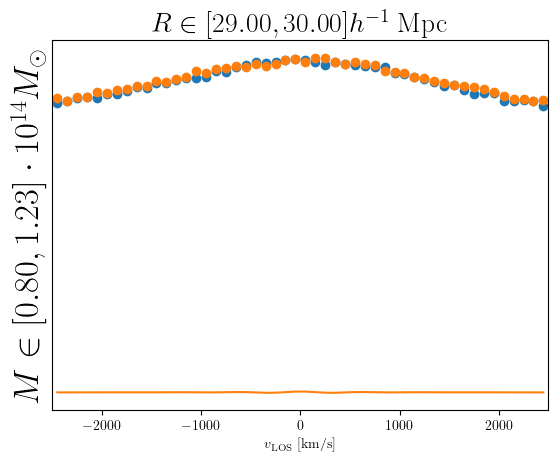

In [131]:
i = 2
k = 0

fig, ax = plt.subplots()

vxs = np.linspace(-2_500, 2_500, 150) 
R = cens[select_indices[i]] 

index2 = select_indices[i] + M_select_indices[k]*len(cens)

nphys, bins = np.histogram(vphyslos_ls[index2], bins=50, range=(-2_500, 2_500), density = False) 
cent = (bins[:-1] + bins[1:])/2.
dv = np.diff(bins)[0]

model_samples = Model_Samples[i + k*len(select_indices)] #P_vphys_R_samples(select_indices[i], M_select_indices[k]) #NOTE: try later with individual masses instead of bin mass. any difference?
nphys_model, bins = np.histogram(model_samples, bins=50, range=(-2_500, 2_500), density = False) 

model_dist = P_vphys_R_vec_quad_fast(cent, cens[select_indices[i]], Mvirs[M_select_indices[k]]/1e14, pars=joint_MAP)
#model_dist = P_vphys_R_fromhists(cent, select_indices[i], M_select_indices[k])
#model_dist = model_dist / np.sum(model_dist*np.diff(vxs)[0])#[valid_ind_smooth:-valid_ind_smooth]
model_phys = np.sum(nphys)*model_dist*np.diff(cent)[0] 

#PD[0, k, i] = (model_phys - nphys)/nphys
#PD[1, k, i] = (model_phys - nphys_model)/nphys_model 

#ax.hist(cent, bins=bins, weights=nphys, color=f"C{str(j)}", histtype='stepfilled', alpha=0.3)
#ax.hist(cent, bins=bins, weights=nphys, color=f"C{str(j)}", histtype='step')
#ax.hist(cent, bins=bins, weights=nphys_model, color=f"C{str(j+1)}", histtype='step')
ax.errorbar(cent, nphys, np.sqrt(nphys), fmt='o', c=f'C0', label='MDPL2')
ax.errorbar(cent, nphys_model, np.sqrt(nphys), fmt='o', c=f'C1', label="Model Samples")

ax.plot(cent, 0.5*(model_phys+np.flip(model_phys)), color=f"C1", label="Numerical Integral")
ax.set_xlabel(r'$v_{\rm LOS}$ [km/s]')
ax.set_ylabel(r'$M \in [{:.2f}, {:.2f}] \cdot 10^{{14}} M_\odot$'.format(M_select_edges[k][0]/1e14, M_select_edges[k][1]/1e14), fontsize=25)
ax.set_yticks([])
ax.set_xticks([-2000, -1000, 0, 1000, 2000])
ax.set_xlim((-2_500, 2_500)) #(vxs[valid_ind_smooth], vxs[-valid_ind_smooth])
ax.set_xlim((-2_500, 2_500)) #(vxs[valid_ind_smooth], vxs[-valid_ind_smooth])
ax.set_title(r'$R \in [{:.2f}, {:.2f}] h^{{-1}}$ Mpc'.format(select_edges[i][0], select_edges[i][1]), fontsize=20)
ax.margins(x=0)

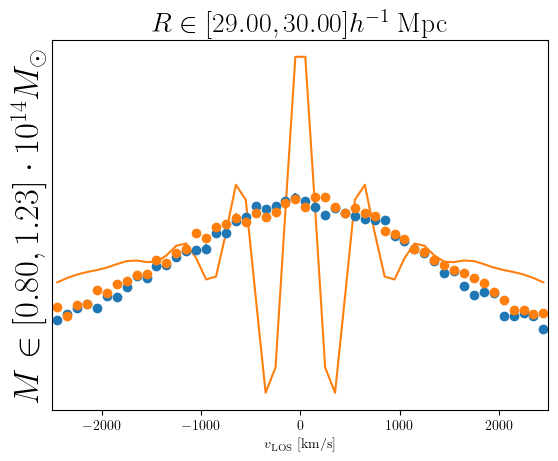

In [136]:
fig, ax = plt.subplots()


model_phys = np.sum(nphys)*model_dist*np.diff(cent)[0] *dv

#PD[0, k, i] = (model_phys - nphys)/nphys
#PD[1, k, i] = (model_phys - nphys_model)/nphys_model 

#ax.hist(cent, bins=bins, weights=nphys, color=f"C{str(j)}", histtype='stepfilled', alpha=0.3)
#ax.hist(cent, bins=bins, weights=nphys, color=f"C{str(j)}", histtype='step')
#ax.hist(cent, bins=bins, weights=nphys_model, color=f"C{str(j+1)}", histtype='step')
ax.errorbar(cent, nphys, np.sqrt(nphys), fmt='o', c=f'C0', label='MDPL2')
ax.errorbar(cent, nphys_model, np.sqrt(nphys), fmt='o', c=f'C1', label="Model Samples")

ax.plot(cent, 0.5*(model_phys+np.flip(model_phys)), color=f"C1", label="Numerical Integral")
ax.set_xlabel(r'$v_{\rm LOS}$ [km/s]')
ax.set_ylabel(r'$M \in [{:.2f}, {:.2f}] \cdot 10^{{14}} M_\odot$'.format(M_select_edges[k][0]/1e14, M_select_edges[k][1]/1e14), fontsize=25)
ax.set_yticks([])
ax.set_xticks([-2000, -1000, 0, 1000, 2000])
ax.set_xlim((-2_500, 2_500)) #(vxs[valid_ind_smooth], vxs[-valid_ind_smooth])
ax.set_xlim((-2_500, 2_500)) #(vxs[valid_ind_smooth], vxs[-valid_ind_smooth])
ax.set_title(r'$R \in [{:.2f}, {:.2f}] h^{{-1}}$ Mpc'.format(select_edges[i][0], select_edges[i][1]), fontsize=20)
ax.margins(x=0)

In [132]:
model_phys

array([477.01618255, 479.23369137, 480.97244063, 481.98544907,
       482.63210288, 483.97320583, 486.40941211, 488.45618697,
       487.9088492 , 485.01729153, 484.08069582, 489.37983259,
       497.98683129, 498.947484  , 484.02468699, 463.23093281,
       463.69552987, 497.86292849, 535.34653215, 525.78442057,
       457.91944214, 390.10394385, 399.22643935, 489.21348859,
       577.51634564, 581.62088092, 505.03437206, 425.66820886,
       407.47415285, 442.76014083, 479.46608732, 486.00704481,
       471.74589162, 458.94902267, 456.28754521, 458.40426842,
       459.19963935, 457.88557686, 456.02354252, 454.47130673,
       453.21038983, 452.0311326 , 450.83297699, 449.60586911,
       448.34332395, 447.00701736, 445.5371198 , 443.85881444,
       441.8666057 , 439.40472287])

In [134]:
nphys

array([43794, 44094, 44426, 44664, 44434, 45093, 45052, 45590, 46147,
       46042, 46702, 46771, 47189, 47496, 47537, 47639, 48467, 48450,
       49106, 49350, 49946, 49750, 49930, 50213, 50377, 50198, 49899,
       49422, 49843, 49547, 49381, 49238, 49187, 49191, 48290, 48072,
       47610, 47392, 46943, 46309, 46419, 45644, 45146, 45304, 45222,
       44027, 44024, 44193, 43995, 43307])

In [81]:
select_indices[-1]

25

In [83]:
v_phys = cent
R_ind = 25
M_ind = 0
R = r_cens[R_ind]
M = Mvirs[M_ind] # * 1e14

h = cosmo.h 
a = 0.83760
redshift=1/a-1
H = h*100*cosmo.Ez(redshift)

rlos_vals = rlos_cens

vpec_data_max = 4000.0

vr_e = np.linspace(-vpec_data_max, vpec_data_max, 100+1)
vr_grid = 0.5*(vr_e[1:]+vr_e[:-1])

vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 

vels = vpeclos_ls

Pvlos_grid = []
for ind in range(len(rlos_cens)):
    vel_data = vels[ind + R_ind*len(rlos_cens) + M_ind*len(r_cens)*len(rlos_cens)]
    
    # Count histogram
    hist, _ = np.histogram(vel_data, bins=vr_e, density=False)

    
    Pvlos_grid.append(hist)

Pvlos_grid = np.array(Pvlos_grid)

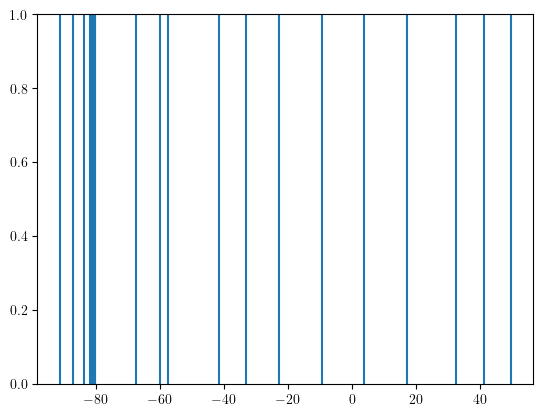

In [97]:
for i in range(len(rlos_cens)//2, len(rlos_cens)):
    #plt.plot(vr_grid, Pvlos_grid[i])
    plt.axvline(np.median(vels[i + R_ind*len(rlos_cens) + M_ind*len(r_cens)*len(rlos_cens)]))

In [95]:
print(i)

20


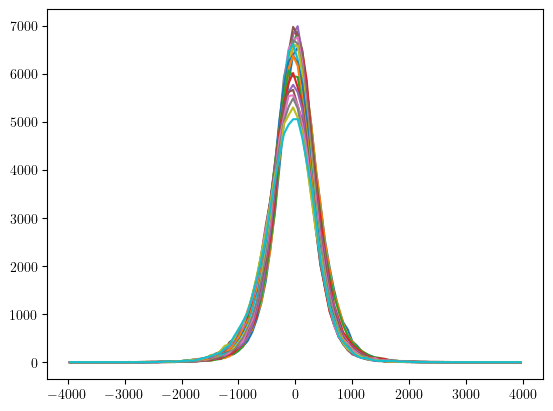

In [88]:
for i in range(len(rlos_cens)//2):
    plt.plot(vr_grid, Pvlos_grid[i+len(rlos_cens)//2])

100%|██████████| 52007/52007 [00:24<00:00, 2157.99it/s]


(60, 50)


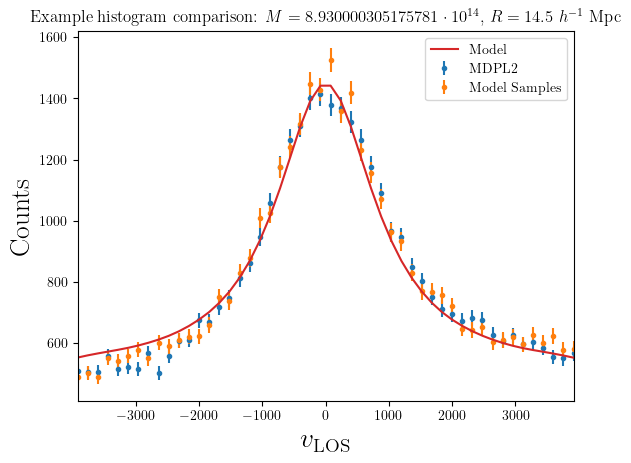

In [5]:
ind = 10
m_ind = 5
index = ind + m_ind*len(r_cens)

test_vlos = vphyslos_ls[index] 
test_R = R_ls[index]
test_rlos = rlos_ls[index]

samp_vr_vt = np.array([joint_dist_samples(1, r=np.sqrt(r_cens[ind]**2 + test_rlos[i]**2), M=Mvirs[m_ind], pars=joint_MAP) for i in tqdm(range(len(test_vlos)))]) # takes ~ 1min to run w/ 52,000 samples

#np.array([joint_dist_samples(len(test_vlos), r=r_cens[ind], M=Mvirs[5], pars=joint_MAP)])

h = cosmo.h 
a = 0.83760
redshift=1/a-1
H = h*100*cosmo.Ez(redshift)
theta_test = np.arctan2(test_rlos, r_cens[ind]) #np.arctan(test_R/test_rlos) #np.arctan(test_R/test_rlos) #np.arctan2(test_R, test_rlos)

cos_test = np.cos(theta_test)
sin_test = np.sin(theta_test)

vpeclos_test =  samp_vr_vt[:, 0, 0]*sin_test + samp_vr_vt[:, 1, 0]*cos_test
#( samp_vr_vt[:, 0, 0]*sin_test + samp_vr_vt[:, 1, 0]*cos_test )

vphyslos_test = vpeclos_test + a*H*test_rlos / h

h2 = np.histogram(test_vlos, bins=bin_num, range=[-4000, 4000])
h1 = np.histogram(vphyslos_test, bins=bin_num, range=[-4000, 4000])

test_vc = 0.5*(h2[1][1:]+h2[1][:-1])

plt.errorbar(test_vc, h2[0], np.sqrt(h2[0]), fmt='o', c='C0', markersize=3, zorder=0, label='MDPL2')
plt.errorbar(test_vc, h1[0], np.sqrt(h1[0]), fmt='o', c='C1', markersize=3, zorder=0, label='Model Samples')

mod_test = P_vphys_R_vec(test_vc, r_cens[ind], Mvirs[m_ind]/1e14, joint_MAP)
mod_test = mod_test / np.sum(mod_test*np.diff(test_vc)[0])


model_counts = np.sum(h2[0])*mod_test*np.diff(test_vc)[0]
plt.plot(test_vc, model_counts, c='C3', label='Model')
#plt.plot(test_vc, np.sum(h2[0])*mod_test*np.diff(test_vc)[0], c='C0')
plt.xlabel(r'$v_{\rm LOS}$', fontsize=20)
plt.ylabel('Counts', fontsize=20)
plt.margins(x=0) 
plt.title(f'Example histogram comparison: $M={ round(Mvirs[m_ind]/1e14, 2) } \cdot 10^{{14}}$, $R={r_cens[ind]} \ h^{{-1}}$ Mpc')
plt.legend()

(60, 50)


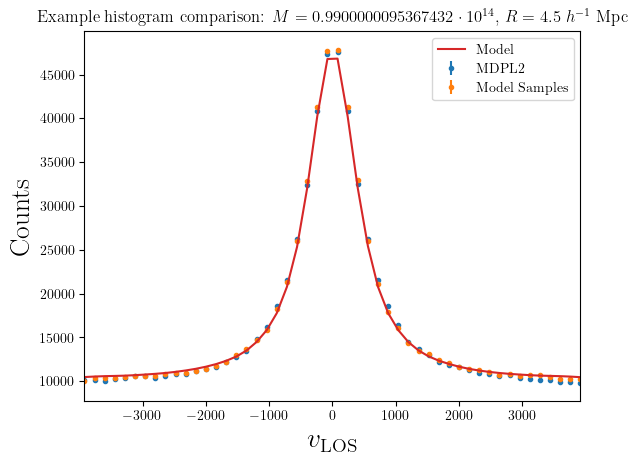

In [ ]:
ind = 10
m_ind = 0
index = ind + m_ind*len(r_cens)

test_vlos = vphyslos_ls[index] 
test_R = R_ls[index]
test_rlos = rlos_ls[index]

# Now you can vectorize the entire operation:
r_distances = np.sqrt(r_cens[ind]**2 + test_rlos**2)

# Single call instead of 52,000 calls!
rad_samps, tan_samps, masks = joint_dist_samples(
    N=len(r_distances), 
    r=r_distances, 
    M=Mvirs[m_ind], 
    pars=joint_MAP
)
# Stack into the format you need
samp_vr_vt = np.stack([rad_samps, tan_samps], axis=1)[:, :, np.newaxis]

h = cosmo.h 
a = 0.83760
redshift=1/a-1
H = h*100*cosmo.Ez(redshift)
theta_test = np.arctan2(test_rlos, r_cens[ind]) #np.arctan(test_R/test_rlos) #np.arctan(test_R/test_rlos) #np.arctan2(test_R, test_rlos)

cos_test = np.cos(theta_test)
sin_test = np.sin(theta_test)

vpeclos_test =  samp_vr_vt[:, 0, 0]*sin_test + samp_vr_vt[:, 1, 0]*cos_test

vphyslos_test = vpeclos_test + a*H*test_rlos / h

h2 = np.histogram(test_vlos, bins=bin_num, range=[-4000, 4000])
h1 = np.histogram(vphyslos_test, bins=bin_num, range=[-4000, 4000])

test_vc = 0.5*(h2[1][1:]+h2[1][:-1])

plt.errorbar(test_vc, h2[0], np.sqrt(h2[0]), fmt='o', c='C0', markersize=3, zorder=0, label='MDPL2')
plt.errorbar(test_vc, h1[0], np.sqrt(h1[0]), fmt='o', c='C1', markersize=3, zorder=0, label='Model Samples')

mod_test = P_vphys_R_vec(test_vc, r_cens[ind], Mvirs[m_ind]/1e14, joint_MAP)
mod_test = mod_test / np.sum(mod_test*np.diff(test_vc)[0])


model_counts = np.sum(h2[0])*mod_test*np.diff(test_vc)[0]
plt.plot(test_vc, model_counts, c='C3', label='Model')
#plt.plot(test_vc, np.sum(h2[0])*mod_test*np.diff(test_vc)[0], c='C0')
plt.xlabel(r'$v_{\rm LOS}$', fontsize=20)
plt.ylabel('Counts', fontsize=20)
plt.margins(x=0) 
plt.title(f'Example histogram comparison: $M={ round(Mvirs[m_ind]/1e14, 2 ) } \cdot 10^{{14}}$, $R={r_cens[ind]} \ h^{{-1}}$ Mpc')
plt.legend()

(60, 50)


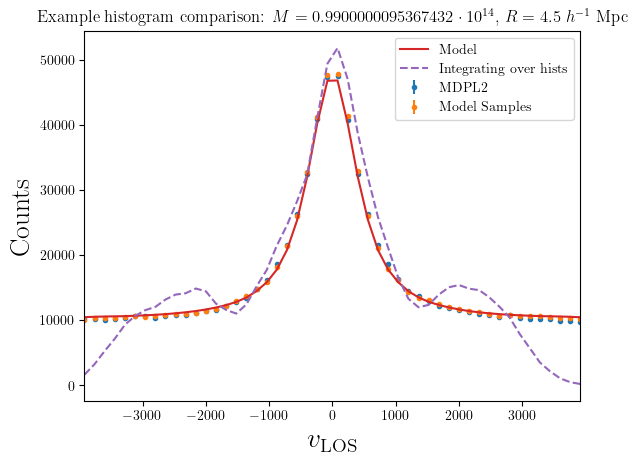

In [29]:
plt.errorbar(test_vc, h2[0], np.sqrt(h2[0]), fmt='o', c='C0', markersize=3, zorder=0, label='MDPL2')
plt.errorbar(test_vc, h1[0], np.sqrt(h1[0]), fmt='o', c='C1', markersize=3, zorder=0, label='Model Samples')

mod_test = P_vphys_R_vec(test_vc, r_cens[ind], Mvirs[m_ind]/1e14, joint_MAP)
mod_test = mod_test / np.sum(mod_test*np.diff(test_vc)[0])

mod_test2 = P_vphys_R_fromhists(test_vc, ind, m_ind)
mod_test2 = mod_test2 / np.sum(mod_test2*np.diff(test_vc)[0])

model_counts = np.sum(h2[0])*mod_test*np.diff(test_vc)[0]
model_counts2 = np.sum(h2[0])*mod_test2*np.diff(test_vc)[0]

plt.plot(test_vc, model_counts, c='C3', label='Model')
plt.plot(test_vc, model_counts2, c='C4', ls='--', label='Integrating over hists')
#plt.plot(test_vc, np.sum(h2[0])*mod_test*np.diff(test_vc)[0], c='C0')
plt.xlabel(r'$v_{\rm LOS}$', fontsize=20)
plt.ylabel('Counts', fontsize=20)
plt.margins(x=0)
plt.title(f'Example histogram comparison: $M={ round(Mvirs[m_ind]/1e14, 2) } \cdot 10^{{14}}$, $R={r_cens[ind]} \ h^{{-1}}$ Mpc')
plt.legend()

In [29]:
np.where(r_cens[ind]==r_cens)[0][0]

np.int64(10)

In [24]:
np.where(ind == r_cens)[0]

array([], dtype=int64)

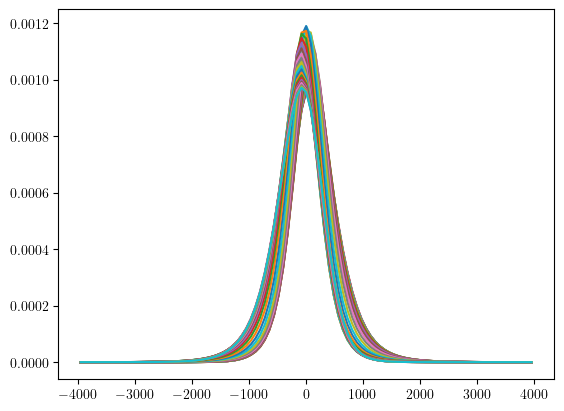

In [9]:
for i in range(40):
    plt.plot(vr_grid, Pvlos_grid[i, :])

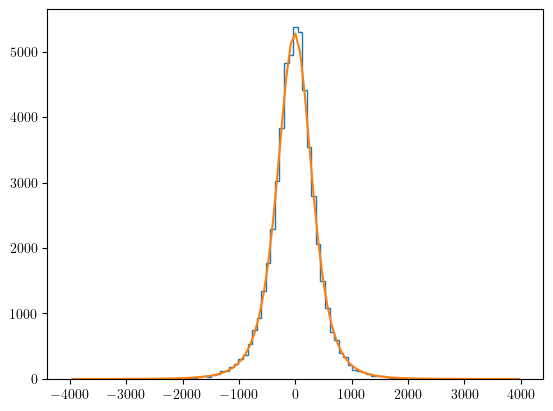

In [14]:
rlos_ind = 20

th = plt.hist(vpeclos[rlos_ind + ind*len(rlos_cens) + m_ind*len(rlos_cens)*len(r_cens)], bins=vr_e, density=False, histtype='step')
plt.plot(vr_grid, np.sum(th[0])*Pvlos_grid[rlos_ind, :]*np.diff(vr_grid)[0])


(-10.0, 10.0)

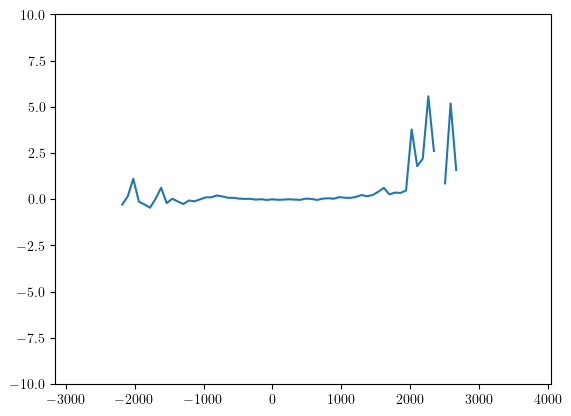

In [18]:
rlos_ind = 15
plt.plot(vr_grid, differences[rlos_ind])

plt.ylim((-10, 10))

In [83]:
len(differences)

20

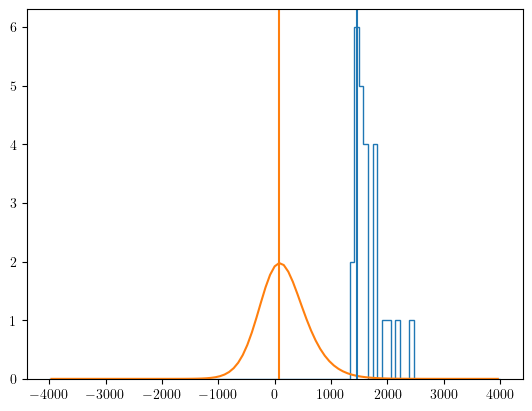

In [74]:
rlos_ind = 0
th = plt.hist(vpeclos[rlos_ind + ind*len(rlos_cens) + m_ind*len(rlos_cens)*len(r_cens)], bins=vr_e, density=False, histtype='step')
#plt.plot(vr_grid, np.sum(th[0])*Pvlos_grid[rlos_ind, :]*np.diff(vr_grid)[0])
plt.plot(vr_grid, np.sum(th[0])*P_vlos_R_rlos(vr_grid, r_cens[ind], r_los=rlos_cens[rlos_ind], M=Mvirs[m_ind], pars=pars)*np.diff(vr_grid)[0])

plt.axvline(vr_grid[np.argmax(th[0])], c='C0')
plt.axvline(vr_grid[np.argmax(P_vlos_R_rlos(vr_grid, r_cens[ind], r_los=rlos_cens[rlos_ind], M=Mvirs[m_ind], pars=pars))], c='C1') 

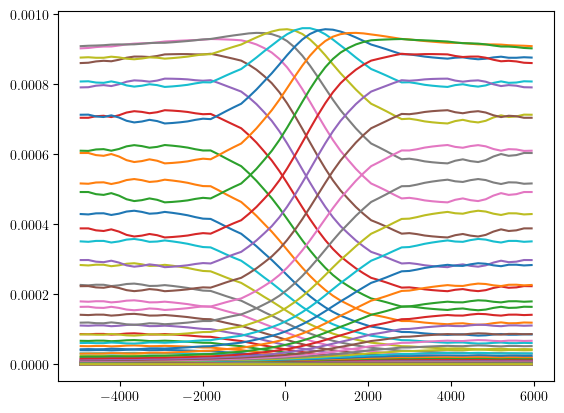

In [23]:
for i in range(99):
    plt.plot(vpec, Pvlos_grid[:, i])
#plt.yscale('log')

In [41]:
r_edges

array([ 4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16.,
       17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29.,
       30.])

In [42]:
len(r_cens)*len(rlos_cens)*len(Mvirs)

9360

Number of bins: 6240
Number of bins: 6240
